Using device: cuda
GPU: NVIDIA GeForce RTX 5080
X shape: (400, 200, 6)
X_changed shape: (400, 200, 6)
U shape: (400, 199, 2)
离线数据已保存。


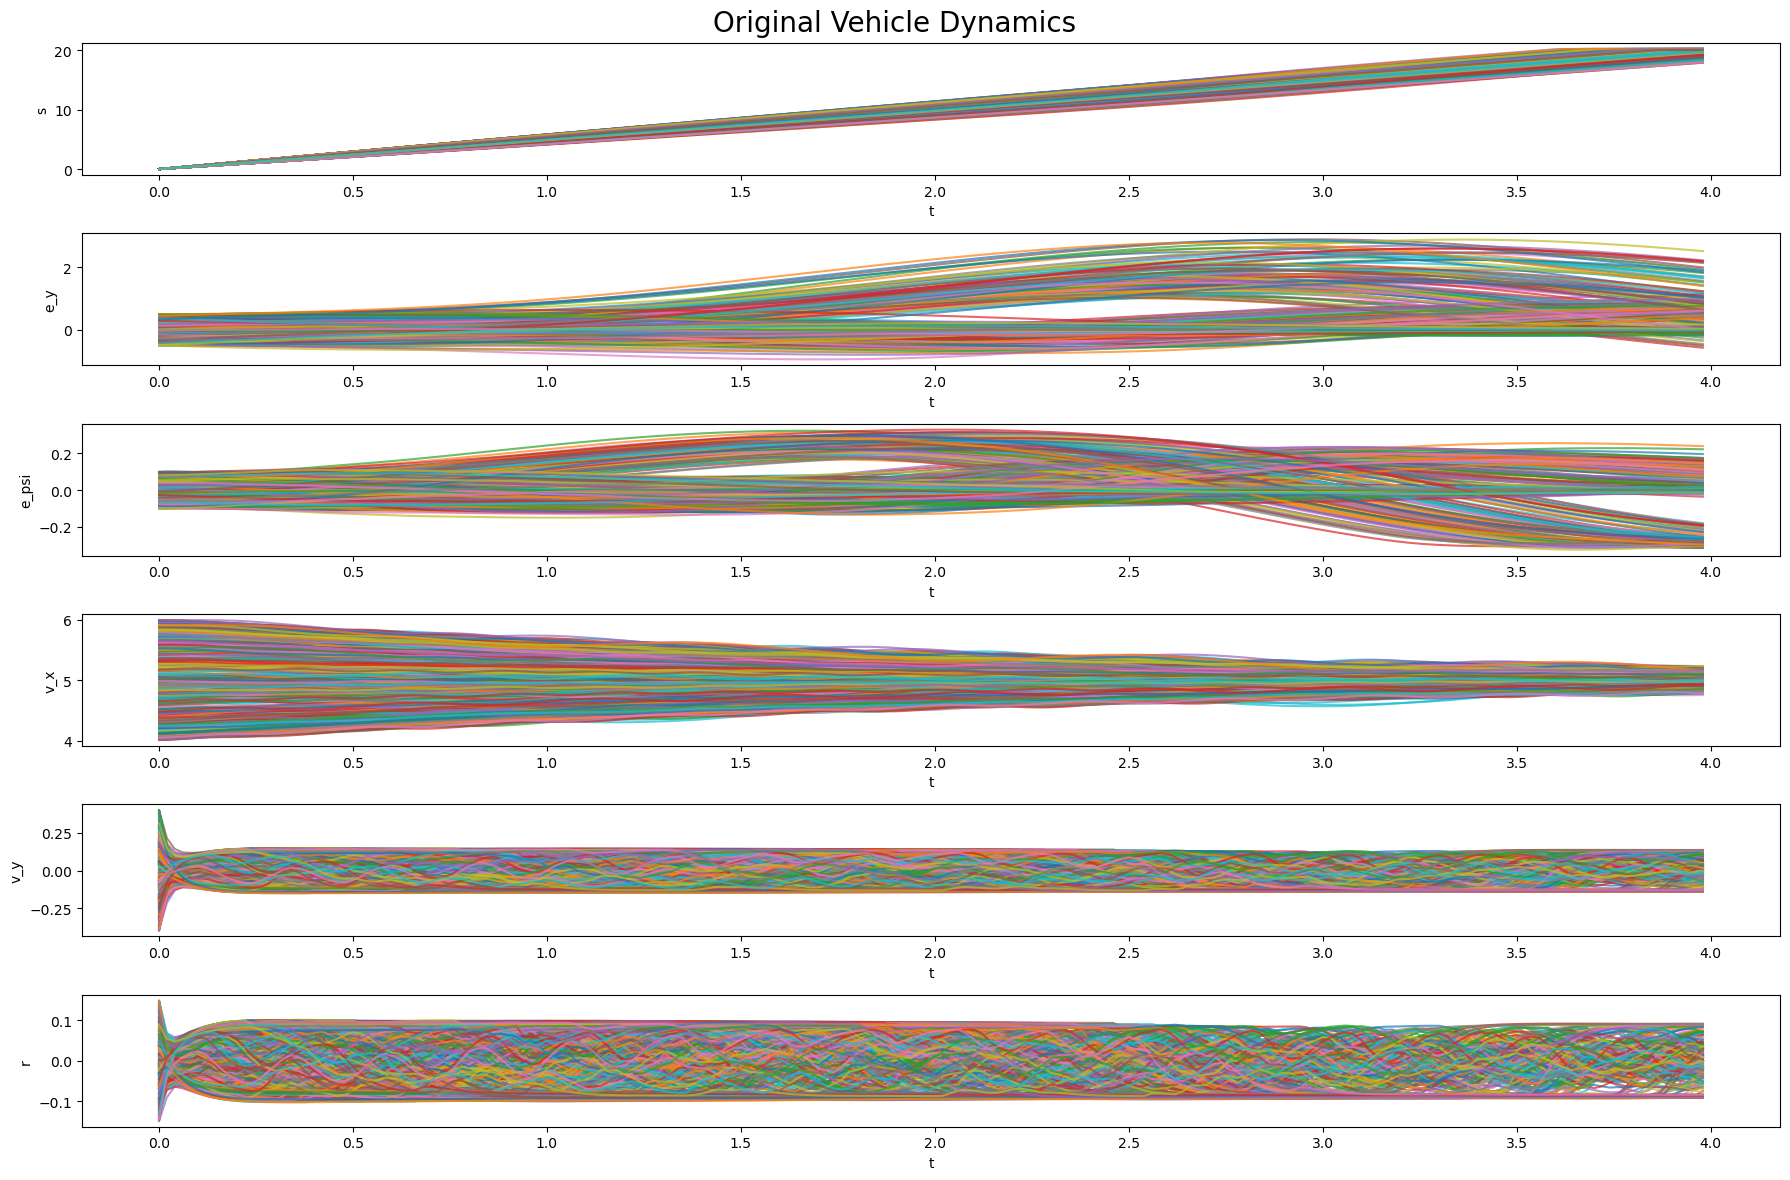

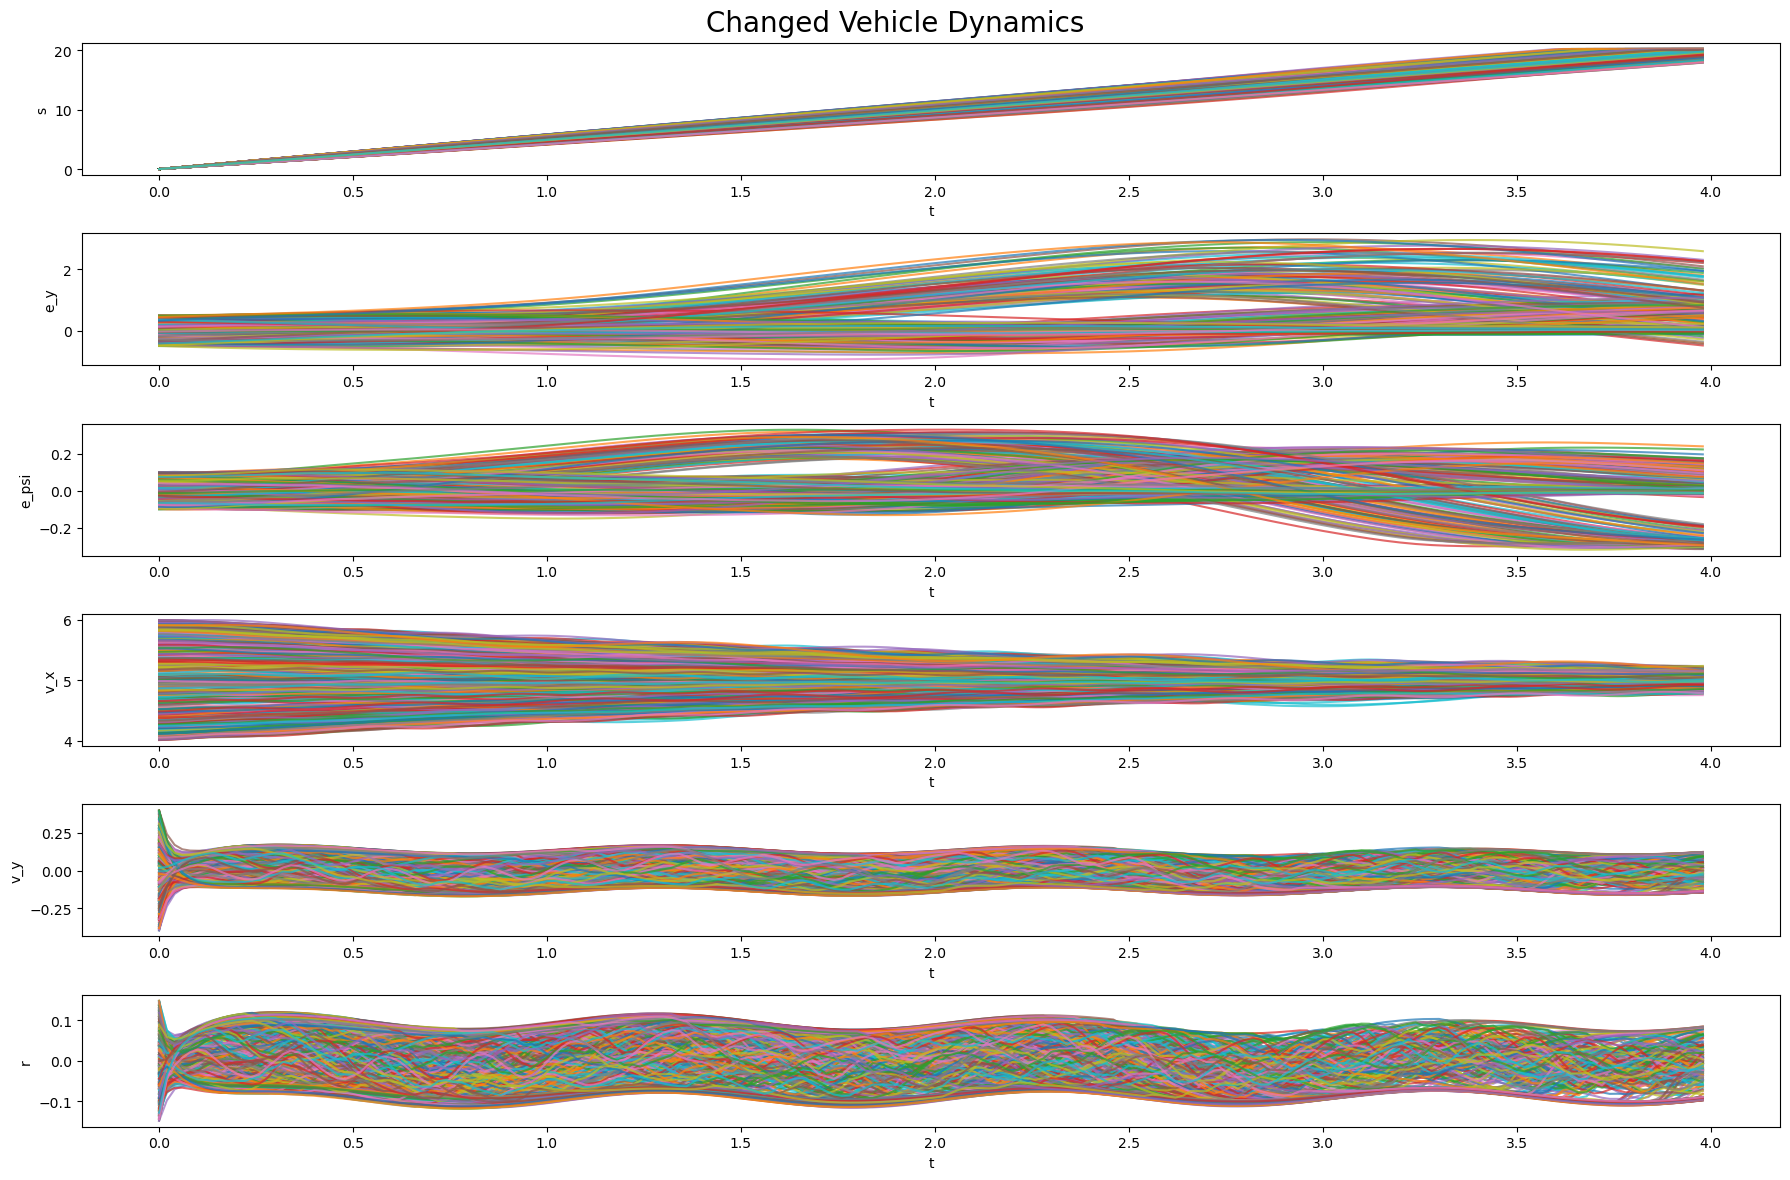

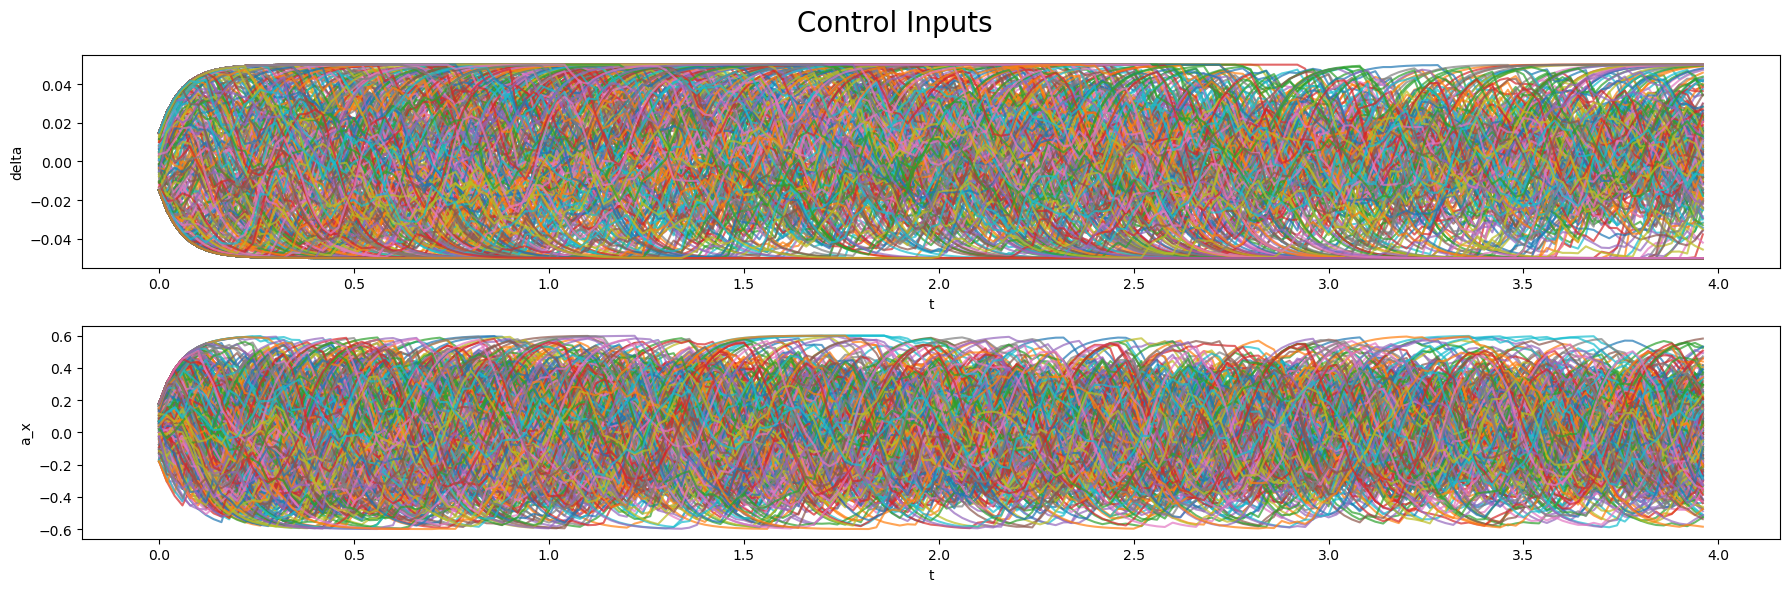

xs_train shape: (320, 200, 6)
us_train shape: (320, 199, 2)
Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim16_dt_0.02.pth
Epoch   1: train loss: 3.0930912284, validation loss: 1.2896178762
Epoch   2: train loss: 1.0894931947, validation loss: 0.9633687342
Epoch   3: train loss: 0.8994153855, validation loss: 0.8461503755
Epoch   4: train loss: 0.8087723281, validation loss: 0.7749933775
Epoch   5: train loss: 0.7464589003, validation loss: 0.7165078000
Epoch   6: train loss: 0.6962623196, validation loss: 0.6715561170
Epoch   7: train loss: 0.6537005796, validation loss: 0.6328161624
Epoch   8: train loss: 0.6171734479, validation loss: 0.5968384904
Epoch   9: train loss: 0.5832631620, validation loss: 0.5614608720
Epoch  10: train loss: 0.5527103938, validation loss: 0.5344907206
Epoch  11: train loss: 0.5243870992, validation loss: 0.5041214928
Epoch  12: train loss: 0.4980105959, validation loss: 0.4778050806
Epoch  13: train loss: 0.4730024584, validation loss:

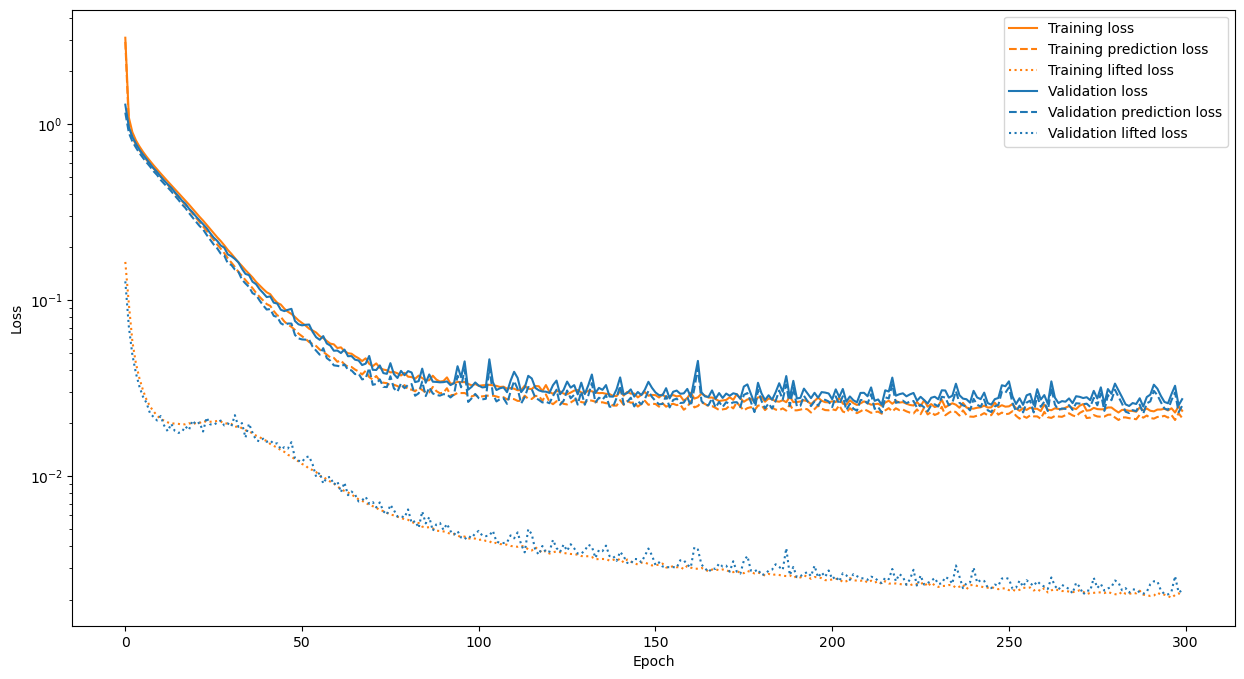

test shapes: (1, 100, 6) (1, 100, 6) (1, 99, 2)
stable spectral radius = 0.9990006
A, B, C shapes: (23, 23) (23, 2) (6, 23)
spectral radius = 1.0157833
eigvals = [0.3314776 +0.j         0.44108772+0.j         0.955239  +0.18983957j
 0.955239  -0.18983957j 1.0005758 +0.04070954j 1.0005758 -0.04070954j
 1.0013261 +0.0319839j  1.0013261 -0.0319839j  1.0157833 +0.j
 0.98701304+0.00865071j 0.98701304-0.00865071j 1.0073909 +0.00788702j
 1.0073909 -0.00788702j 1.0010426 +0.01070763j 1.0010426 -0.01070763j
 1.0075709 +0.j         0.9932744 +0.00878099j 0.9932744 -0.00878099j
 0.994887  +0.j         0.99346036+0.00384172j 0.99346036-0.00384172j
 1.0000001 +0.j         1.        +0.j        ]


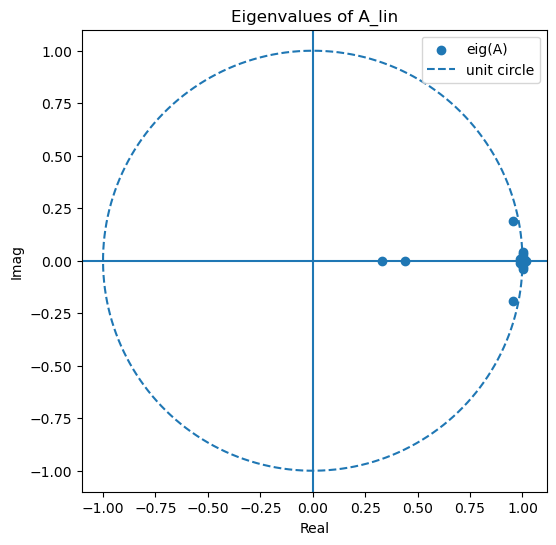

x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 6)


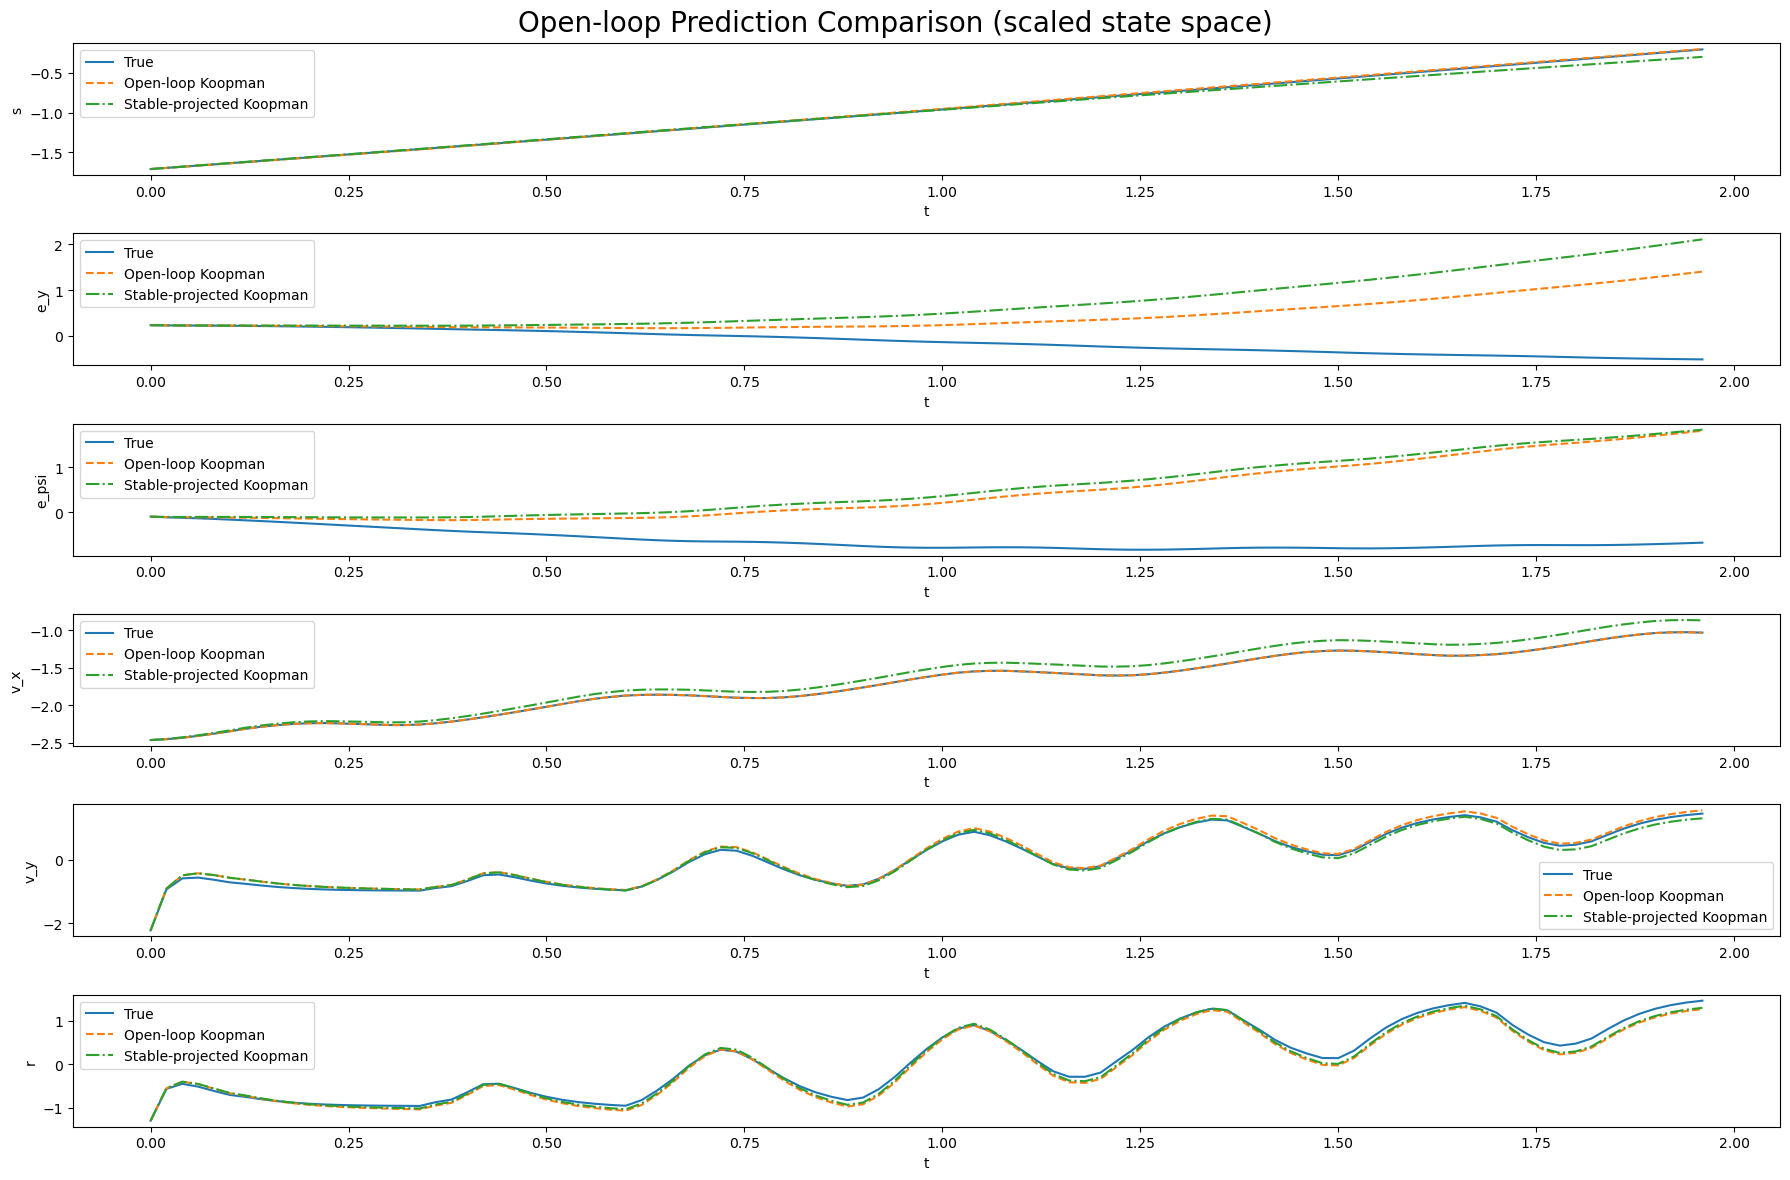

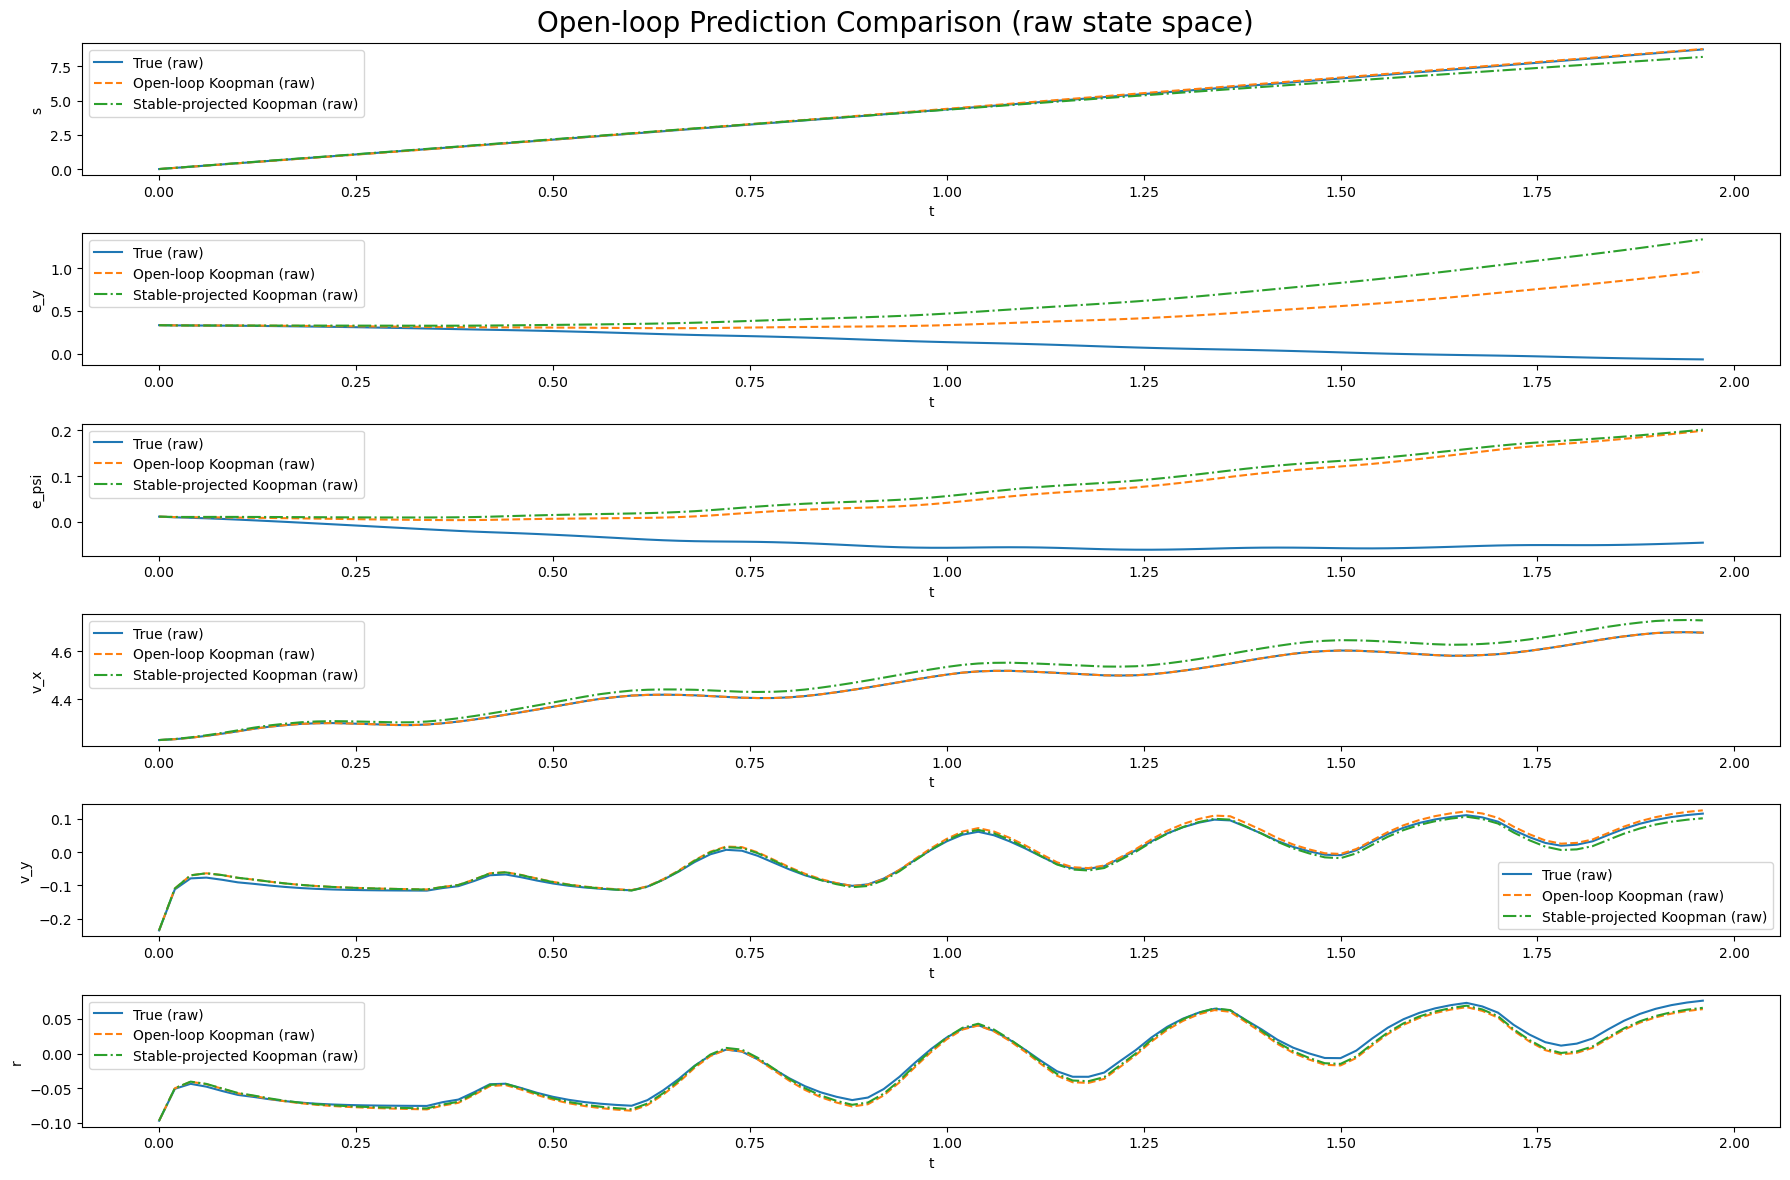

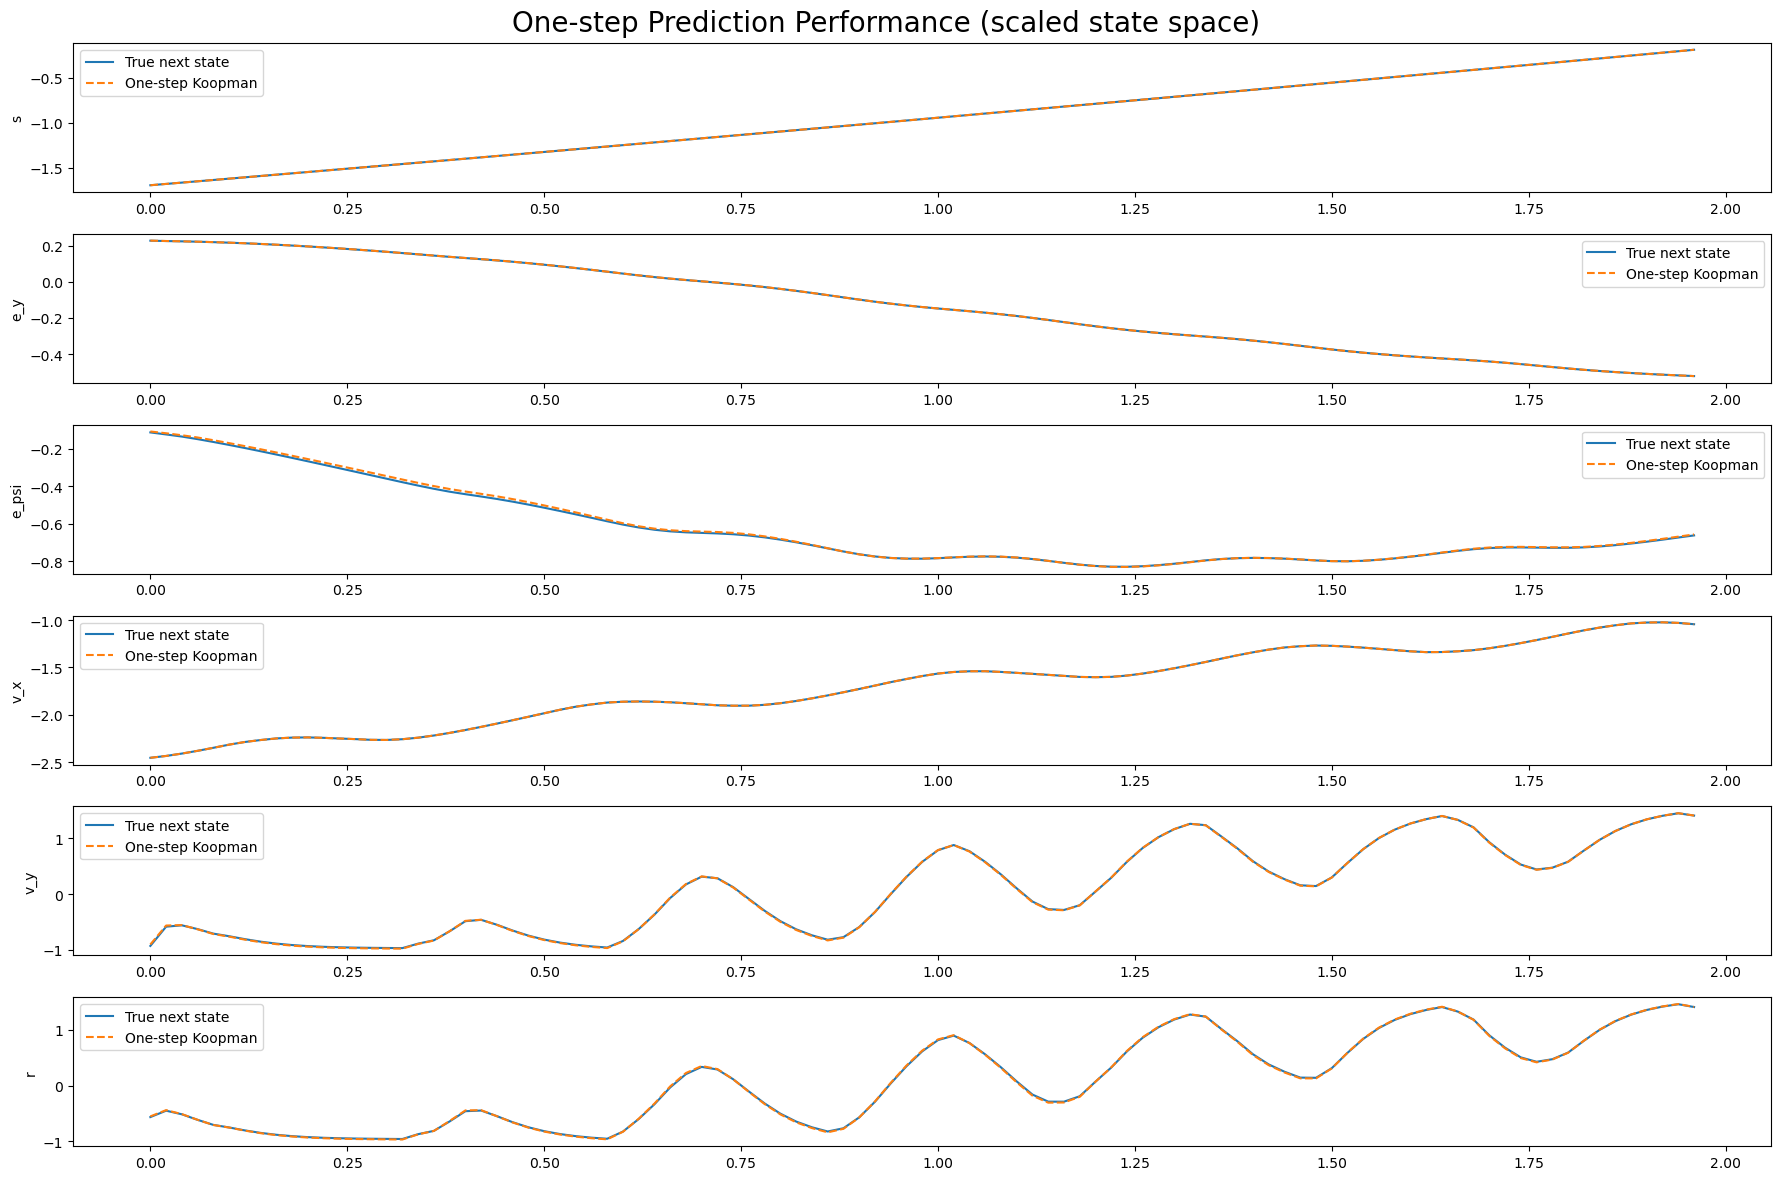

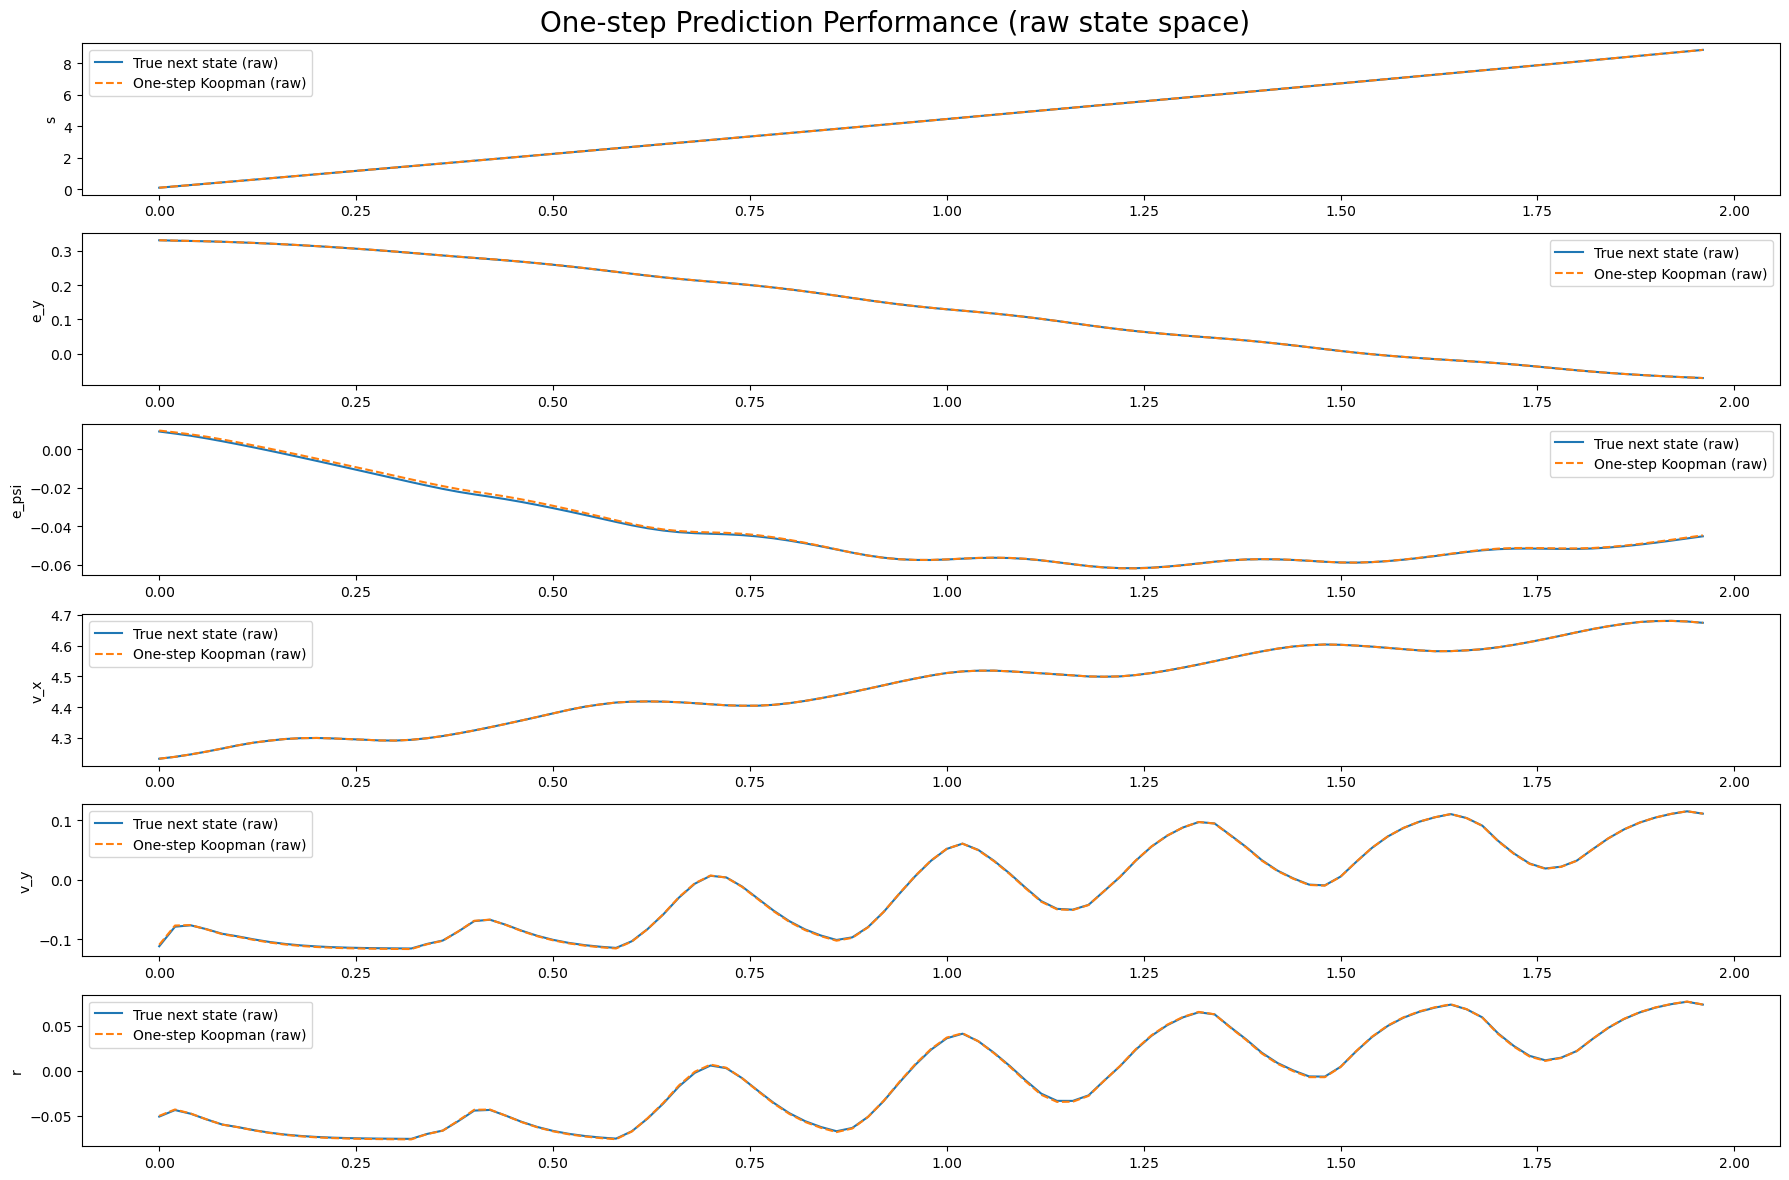

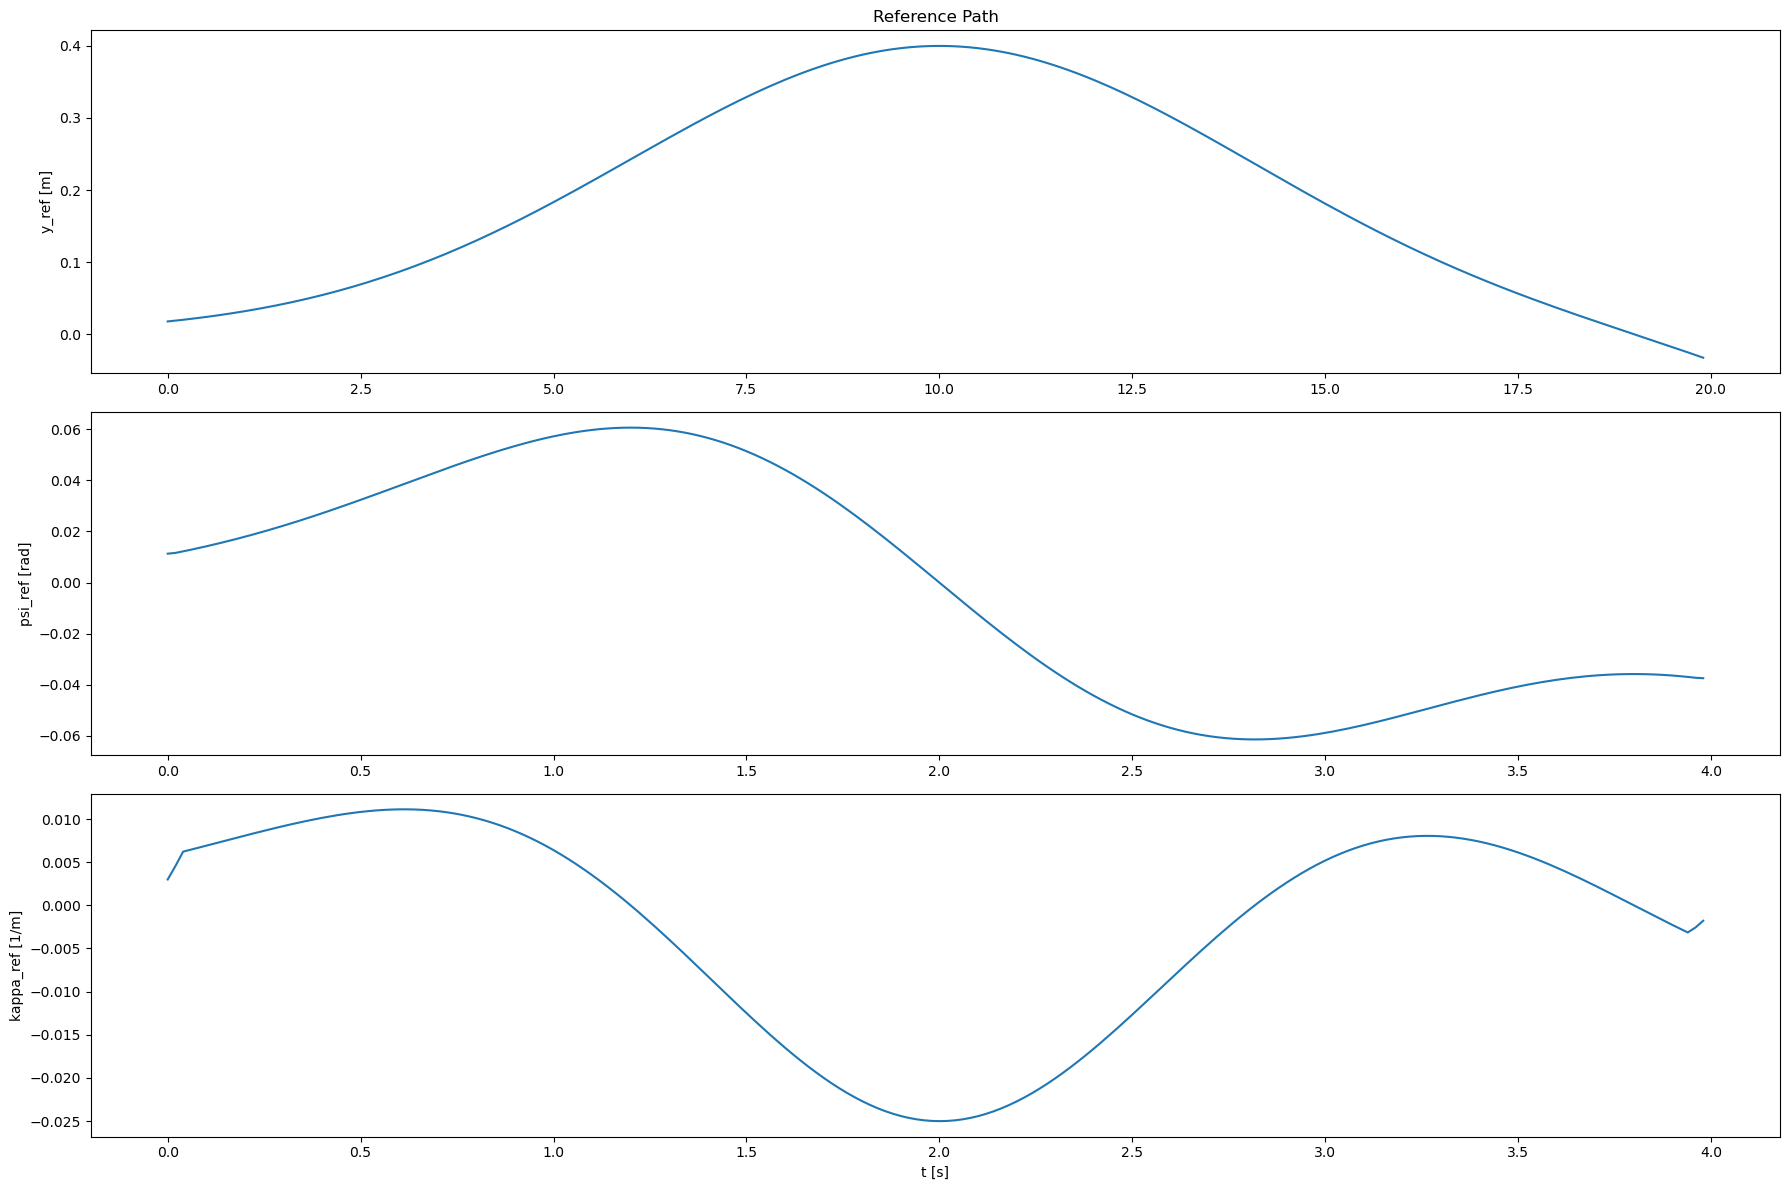

A finite: True
B finite: True
C finite: True
A shape: (23, 23) B shape: (23, 2) C shape: (6, 23)
raw spectral radius = 1.0157833
stable spectral radius = 0.9990006
z_init finite: True
z_init norm: 15.365240745161397

========== feasibility diagnostics before MPC ==========
x0 real    : [0. 0. 0. 5. 0. 0.]
x0 decoded : [-1.7088902  -0.38895825 -0.20580961 -0.00690375  0.24234648  0.24330847]
decode err : [-1.7088902  -0.38895825 -0.20580961 -5.00690375  0.24234648  0.24330847]
decoded lower slack: [ 8.2911098   9.61104175  1.79419039  0.99309625 10.24234648  5.24330847]
decoded upper slack: [501.7088902   10.38895825   2.20580961  30.00690375   9.75765352
   4.75669153]

--- step 0 ---
x real   : [0. 0. 0. 5. 0. 0.]
x decode : [-1.7088902  -0.38895825 -0.20580961 -0.00690375  0.24234648  0.24330847]
decode err: [-1.7088902  -0.38895825 -0.20580961 -5.00690375  0.24234648  0.24330847]
lower slack: [ 8.2911098   9.61104175  1.79419039  0.99309625 10.24234648  5.24330847]
upper slack: [501

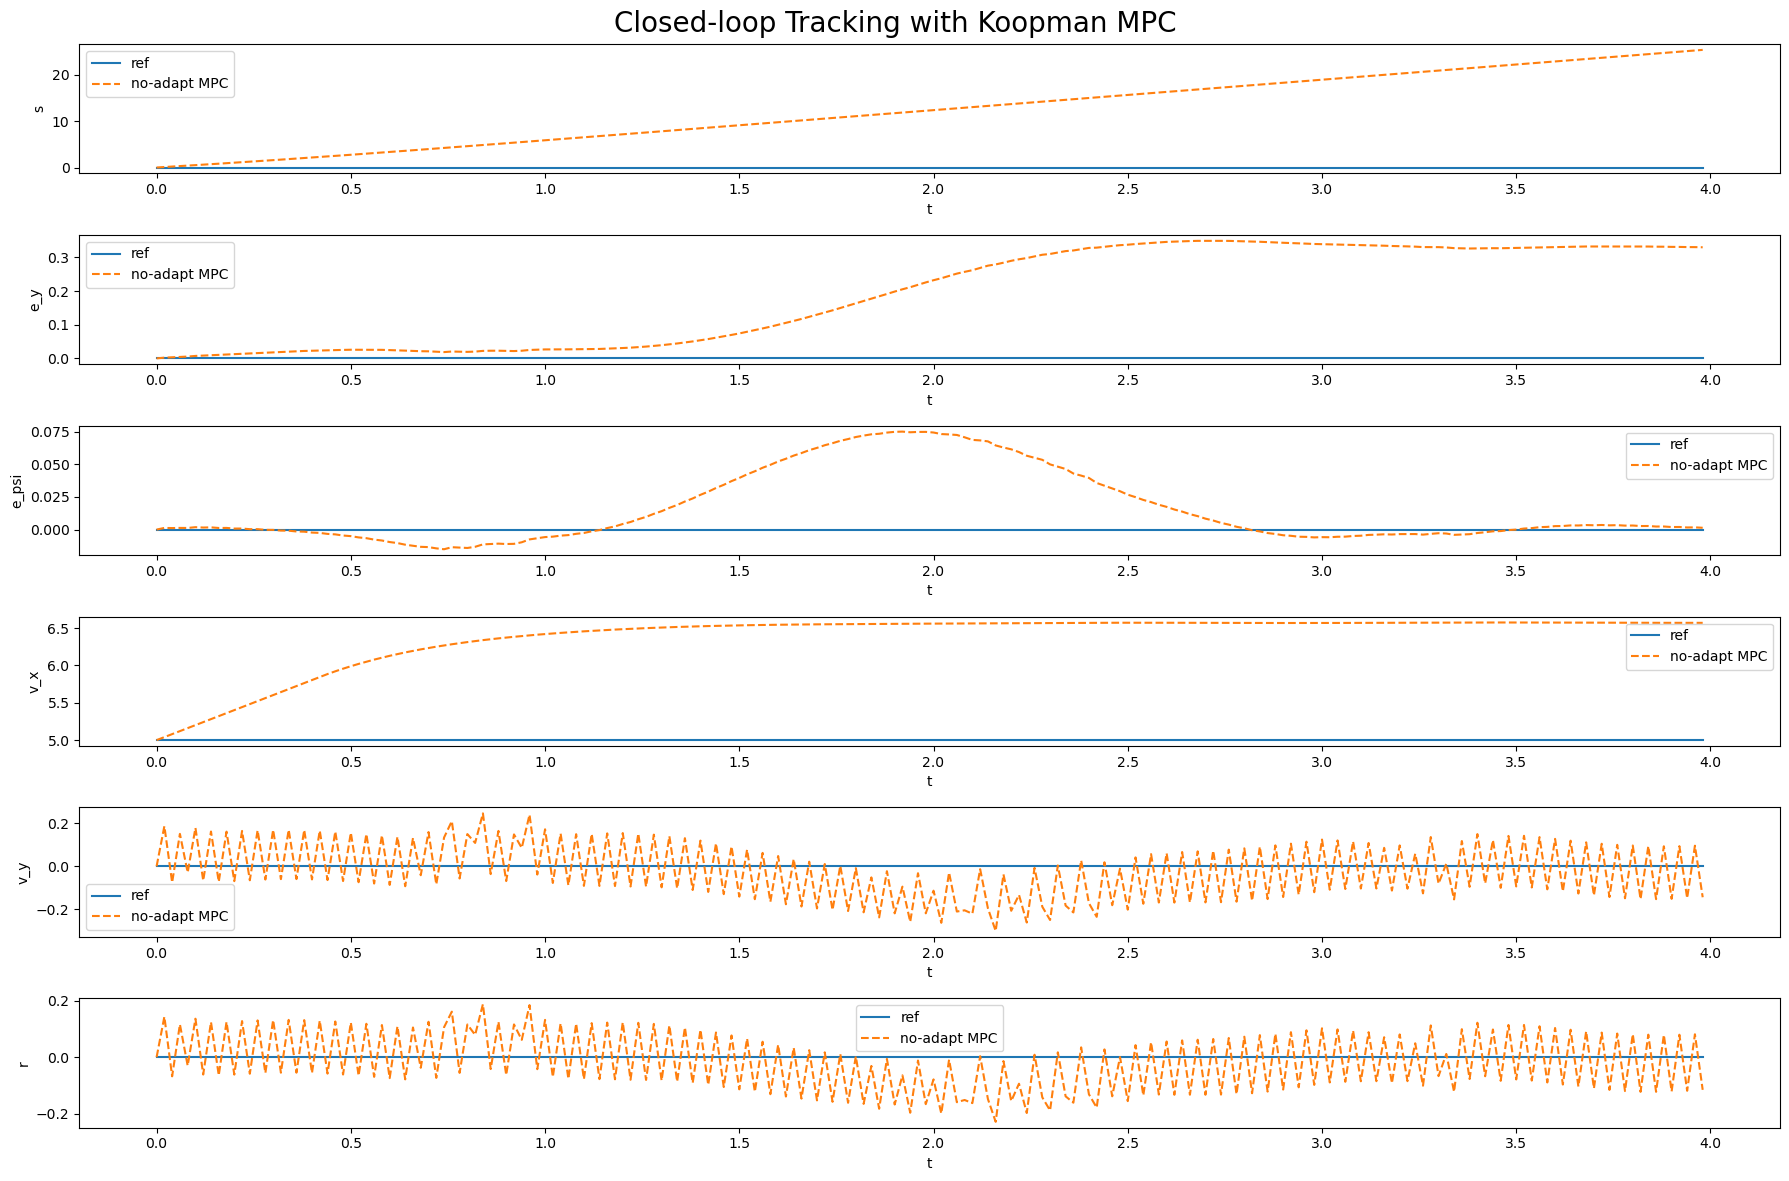

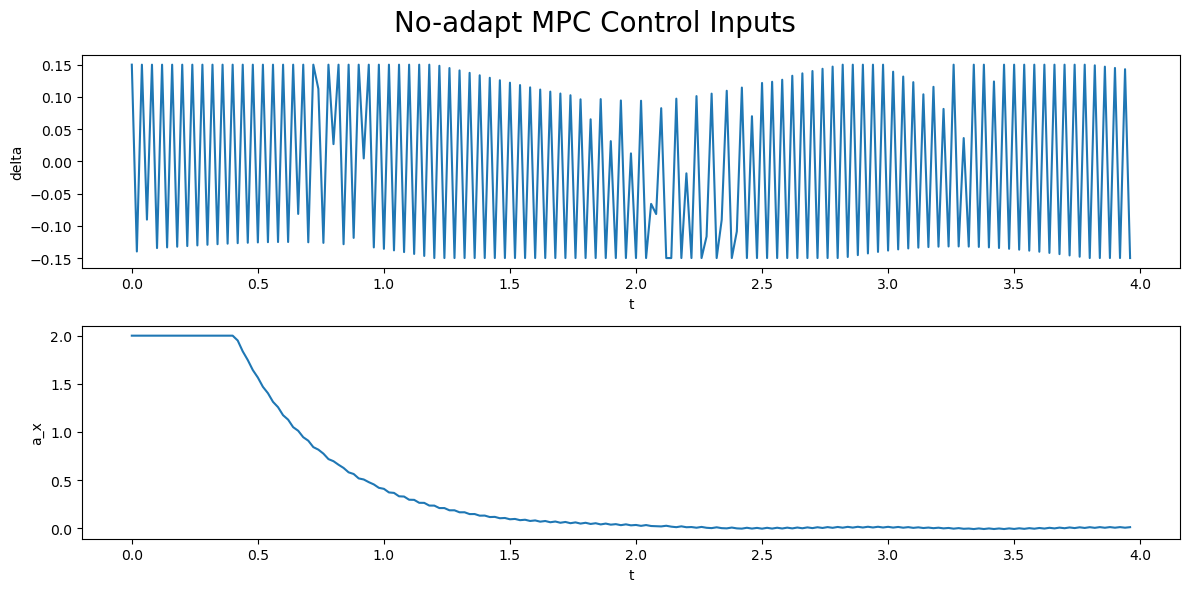

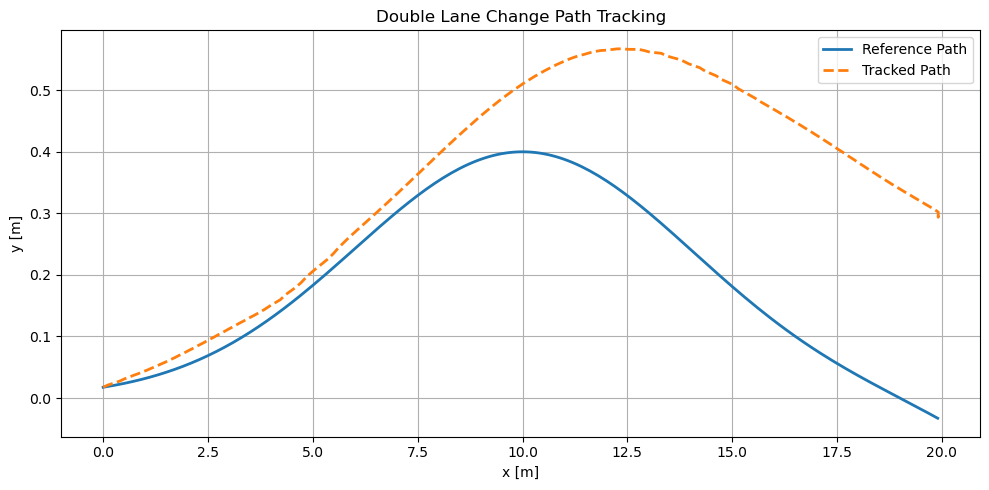

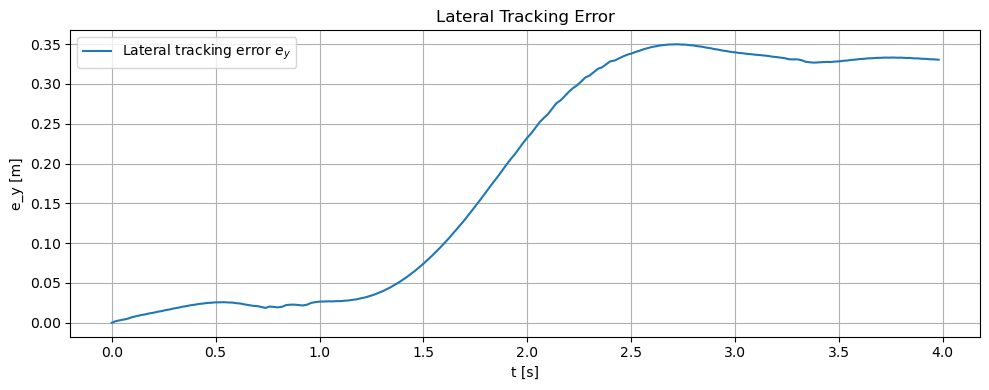

Assumed lifted index for s = 1
z0_check shape: (23,)
decoded x0 from lifted: [-1.7088902  -0.38895825 -0.20580961 -0.00690375  0.24234648  0.24330847]
real x0: [0. 0. 0. 5. 0. 0.]
Entered adaptation branch at k = 25
k=25
||Z_obs|| = 17.246929741307813
||U_obs|| = 8.639735341250534
||del_Z_prime|| = 12.002781409930028
||del_A_ctrl_lin|| = 0.0052250116
||del_B_ctrl_lin|| = 0.0015517547
k=26
||Z_obs|| = 17.428285298497105
||U_obs|| = 8.537819927047675
||del_Z_prime|| = 12.330982594016534
||del_A_ctrl_lin|| = 0.0052453745
||del_B_ctrl_lin|| = 0.001550885
k=50
||Z_obs|| = 22.47335504797465
||U_obs|| = 3.750592927272706
||del_Z_prime|| = 12.822685169138568
||del_A_ctrl_lin|| = 0.0052486015
||del_B_ctrl_lin|| = 0.0015522857
Average adaptive MPC solve time per step = 0.015105282241974645


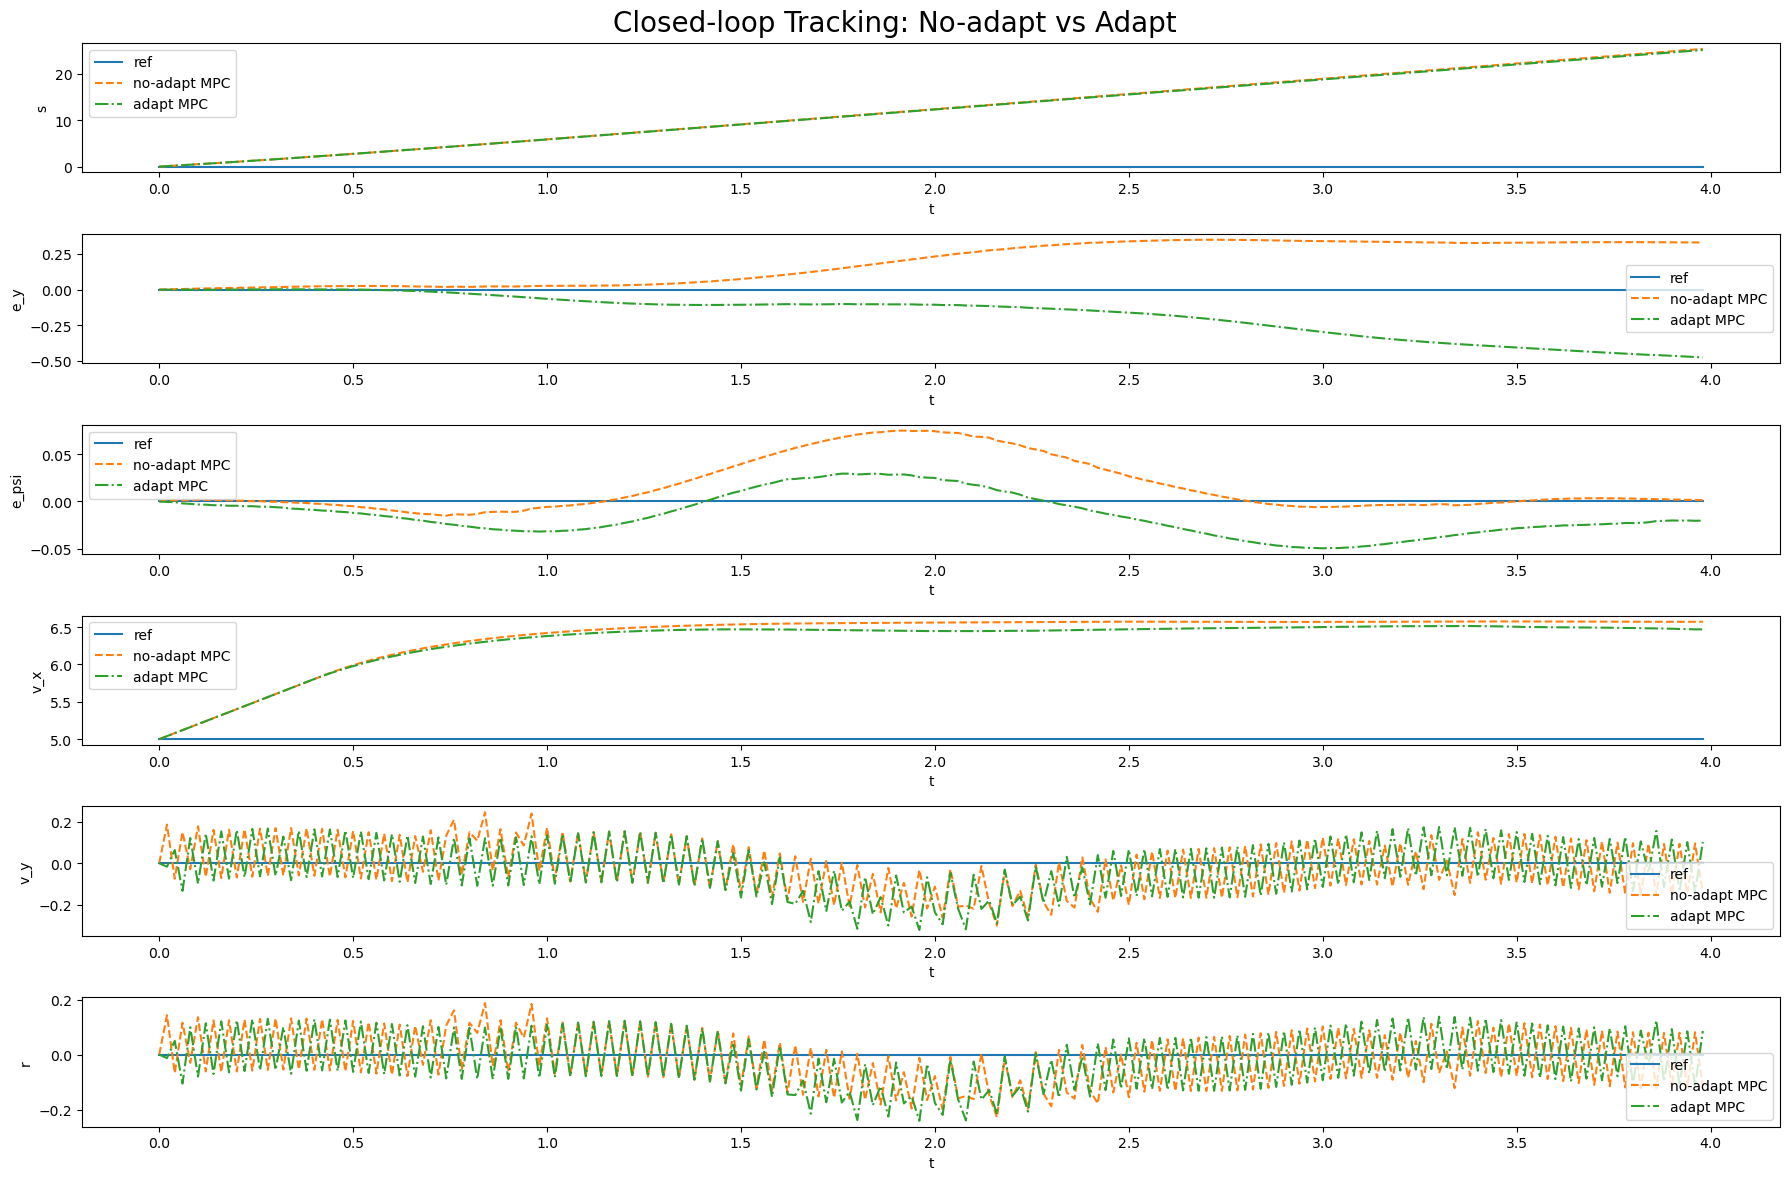

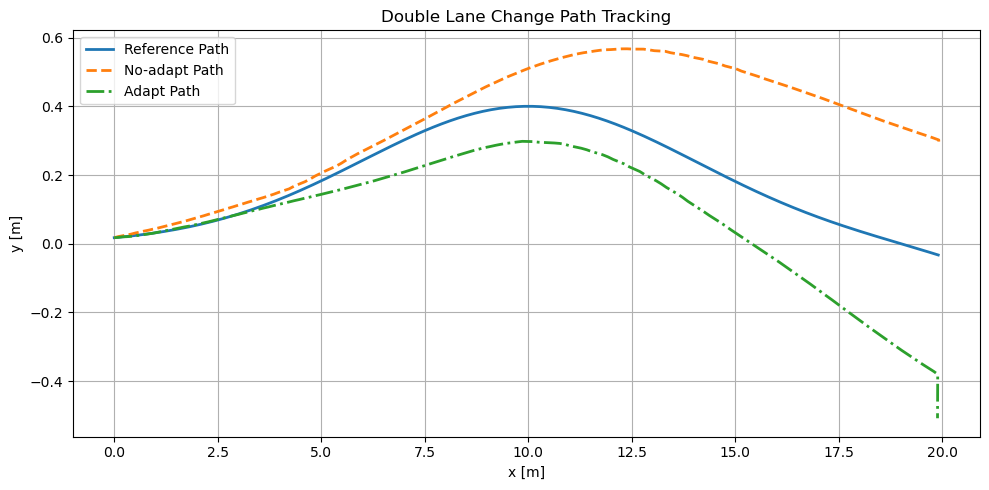

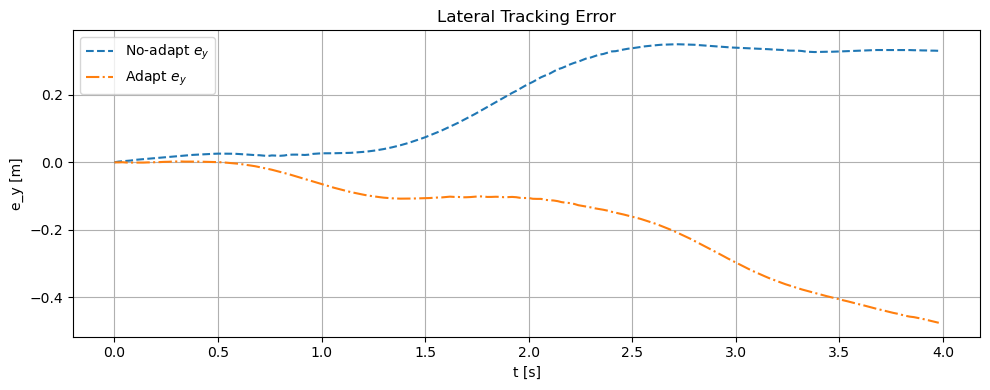

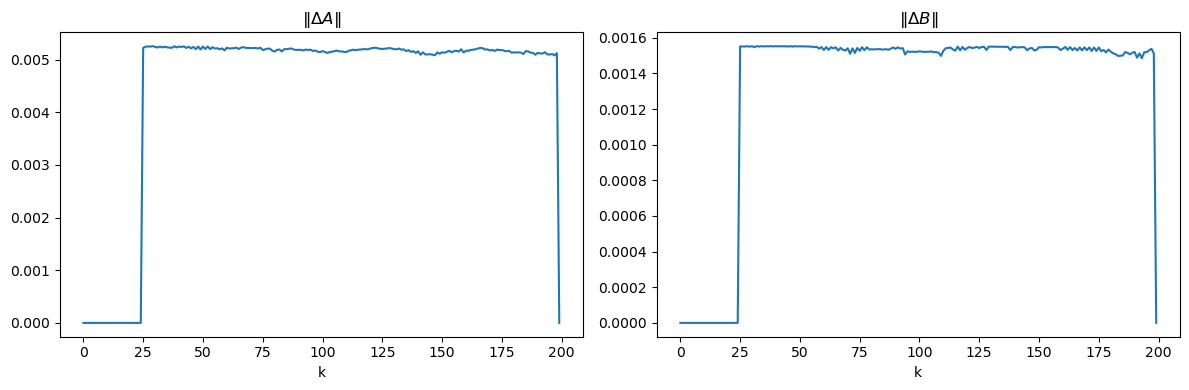

In [1]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# Import Adaptive Koopman
from core.adapt_net_linear import AdaptNet_linear

# ===== [CHANGED_FOR_CACANEW: import new Frenet-real-state dynamics file] =====
import dynamics.cacaNEW as cacaNEW

importlib.reload(cacaNEW)
from dynamics.cacaNEW import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics


# ===== [FIXED: helper for test/reference Frenet path] =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    # 用相邻点距离计算弧长，避免 gradient + cumsum 带来的偏差
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== [NEW: Frenet -> Cartesian for plotting] =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.array(x)


## 系统拟合
"""Choose the type of Koopman representation"""
linear = True

## 数据生成
# define system pars
sys_pars = {}

# ===== [CHANGED_FOR_CACANEW: 5 -> 6 states, x=[s, e_y, e_psi, v_x, v_y, r]] =====
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars['num_states'] = num_states
sys_pars['num_inputs'] = num_inputs
sys_pars['dt'] = dt

# vehicle parameters
sys_pars['m'] = 1500.0
sys_pars['Iz'] = 2250.0
sys_pars['lf'] = 1.2
sys_pars['lr'] = 1.6
sys_pars['Cf'] = 80000.0
sys_pars['Cr'] = 80000.0
sys_pars['vx_ref'] = 5.0
# ===== [CHANGED_FOR_CACANEW: curvature is no longer injected as a scalar into data generation] =====
sys_pars['curvature_ref'] = 0.0

# input generation
sys_pars['U_type'] = 'sinusoidal'
sys_pars['delta_max'] = 0.05
sys_pars['ax_max'] = 0.6

# uncertainty setting
sys_pars['uncertainty'] = 'NA'
sys_pars['amp'] = 0.0
sys_pars['freq'] = 1.0

sys_pars_new = {}

sys_pars_new['num_states'] = num_states
sys_pars_new['num_inputs'] = num_inputs
sys_pars_new['dt'] = dt

# changed vehicle parameters
sys_pars_new['m'] = 1650.0
sys_pars_new['Iz'] = 2400.0
sys_pars_new['lf'] = 1.2
sys_pars_new['lr'] = 1.6
sys_pars_new['Cf'] = 70000.0
sys_pars_new['Cr'] = 70000.0
sys_pars_new['vx_ref'] = 8.0
sys_pars_new['curvature_ref'] = 0.0

sys_pars_new['U_type'] = sys_pars['U_type']
sys_pars_new['delta_max'] = sys_pars['delta_max']
sys_pars_new['ax_max'] = sys_pars['ax_max']

sys_pars_new['uncertainty'] = 'periodic'
sys_pars_new['amp'] = 0.02
sys_pars_new['freq'] = 1.0

sensor_noise = False
SNR_DB = 30

num_traj = 400
num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

num_snaps = 200

X, X_changed, U = single_vehicle_data_gen_multi(
    num_traj, num_snaps, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)
print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

# 1) 保存轨迹数组
np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

# 2) 保存参数字典
with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

# ===== [CHANGED_FOR_CACANEW: simplified image/model path to avoid undefined percent_change branch] =====
if sys_pars_new['uncertainty'] == 'constant':
    if sensor_noise:
        img_pth = 'saved_models/single_vehicle/linear/nonparametric/constant/sensor_noise/' + str(
            sys_pars_new['amp']) + '/' + str(SNR_DB)
    else:
        img_pth = 'saved_models/single_vehicle/linear/nonparametric/constant/no_sensor_noise/' + str(
            sys_pars_new['amp'])
elif sys_pars_new['uncertainty'] == 'periodic':
    if sensor_noise:
        img_pth = 'saved_models/single_vehicle/linear/nonparametric/periodic/sensor_noise/' + str(
            sys_pars_new['freq']) + '/' + str(SNR_DB)
    else:
        img_pth = 'saved_models/single_vehicle/linear/nonparametric/periodic/no_sensor_noise/' + str(
            sys_pars_new['freq'])
else:
    if sensor_noise:
        img_pth = 'saved_models/single_vehicle/linear/parametric/sensor_noise/' + str(SNR_DB)
    else:
        img_pth = 'saved_models/single_vehicle/linear/parametric/no_sensor_noise'

# ===== [CHANGED_FOR_CACANEW: state labels updated for Frenet real-state model] =====
state_labels = ['s', 'e_y', 'e_psi', 'v_x', 'v_y', 'r']
input_labels = ['delta', 'a_x']
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

## Learning Koopman 生成拟合模型
# split training and validation datasets
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

print("xs_train shape:", xs_train.shape)
print("us_train shape:", us_train.shape)

net_params_lin = {}
net_params_lin['state_dim'] = num_states
net_params_lin['ctrl_dim'] = num_inputs
net_params_lin['encoder_hidden_width'] = 128
net_params_lin['encoder_hidden_depth'] = 3
net_params_lin['encoder_output_dim'] = 16
net_params_lin['optimizer'] = 'adam'
net_params_lin['activation_type'] = 'tanh'
net_params_lin['lr'] = 2e-4
net_params_lin['epochs'] = 300
net_params_lin['batch_size'] = 256

net_params_lin['eig_loss'] = True
net_params_lin['eig_loss_coeff'] = 1.0
net_params_lin['lifted_loss_penalty'] = 1.0

net_params_lin['l2_reg'] = 1e-5
net_params_lin['l1_reg'] = 1e-7
net_params_lin['first_obs_const'] = True
net_params_lin['override_C'] = True
net_params_lin['dt'] = dt

train = True
standardize = True

os.makedirs('saved_models/single_vehicle/linear', exist_ok=True)

file_koop_linear = (
        'saved_models/single_vehicle/linear/'
        + 'Koop_vehicle_Dim'
        + str(net_params_lin['encoder_output_dim'])
        + '_dt_'
        + str(dt)
        + '.pth'
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )
    model_koop_dnn_lin.model_pipeline(net_params_lin)
    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

print("Model parameter device:", next(model_koop_dnn_lin.net.parameters()).device)

train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin['epochs'])

plt.figure(figsize=(15, 8))
plt.plot(epochs, train_loss, color='tab:orange', label='Training loss')
plt.plot(epochs, train_pred_loss, '--', color='tab:orange', label='Training prediction loss')
plt.plot(epochs, train_lifted_loss, ':', color='tab:orange', label='Training lifted loss')
plt.plot(epochs, val_loss, color='tab:blue', label='Validation loss')
plt.plot(epochs, val_pred_loss, '--', color='tab:blue', label='Validation prediction loss')
plt.plot(epochs, val_lifted_loss, ':', color='tab:blue', label='Validation lifted loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.show()

## Koopman Model Parameters
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin['first_obs_const'])
override_C = net_params_lin['override_C']
if override_C:
    n_obs_lin = int(net_params_lin['encoder_output_dim']) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin['encoder_output_dim']) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

print("test shapes:", x_unchanged_test.shape, x_changed_test.shape, u_test.shape)

A_lin = np.array(model_koop_dnn_lin.A)
B_lin = np.array(model_koop_dnn_lin.B)
C_lin = np.array(model_koop_dnn_lin.C)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label='eig(A)')
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), '--', label='unit circle')
plt.axhline(0)
plt.axvline(0)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.legend()
plt.title('Eigenvalues of A_lin')
plt.axis('equal')
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label='True')
    plt.plot(T_plot, x_est_lin[:, i], '--', label='Open-loop Koopman')
    plt.plot(T_plot, x_est_lin_stable[:, i], '-.', label='Stable-projected Koopman')
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label='True (raw)')
    plt.plot(T_plot, x_est_lin_raw[:, i], '--', label='Open-loop Koopman (raw)')
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], '-.', label='Stable-projected Koopman (raw)')
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_one_step_pred = np.zeros_like(x_unchanged_prime_scaled)

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(x_one_step_pred.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_1, x_unchanged_prime_scaled[:, i], label='True next state')
    plt.plot(T_plot_1, x_one_step_pred[:, i], '--', label='One-step Koopman')
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)
x_true_next_raw = x_unchanged_test[0, 1:, :]

T_plot_raw = np.arange(x_true_next_raw.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label='True next state (raw)')
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], '--', label='One-step Koopman (raw)')
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

## Testing
## Adaptive Koopman with Control

T_traj = 4.0
t_ref = np.arange(0, T_traj, dt)
traj_length = t_ref.size

vx_nom = sys_pars['vx_ref']
x_path = vx_nom * t_ref

A1 = 0.4
A2 = -0.4
x1 = 10.0
x2 = 28.0
sigma1 = 4.0
sigma2 = 4.0

y_ref_path = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(x_path, y_ref_path)

# 参考状态：只跟踪 e_y, e_psi, vx，其余弱化
x_ref = np.zeros((num_states, traj_length))
x_ref[3, :] = vx_nom

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")

plt.tight_layout()
plt.show()

begin_linear_noadapt = time.time()

# Koopman matrices
A_lin = to_numpy(model_koop_dnn_lin.A)
B_lin = to_numpy(model_koop_dnn_lin.B)
C_lin = to_numpy(model_koop_dnn_lin.C)

print("A finite:", np.all(np.isfinite(A_lin)))
print("B finite:", np.all(np.isfinite(B_lin)))
print("C finite:", np.all(np.isfinite(C_lin)))
print("A shape:", A_lin.shape, "B shape:", B_lin.shape, "C shape:", C_lin.shape)

# stable A 仅用于对比，不先用于控制
eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

print("raw spectral radius =", np.max(np.abs(np.linalg.eigvals(A_lin))))
print("stable spectral radius =", np.max(np.abs(np.linalg.eigvals(A_lin_stable))))

# ===== OSQP solver settings =====
solver_settings = {}
solver_settings['gen_embedded_ctrl'] = False
solver_settings['warm_start'] = True
solver_settings['polish'] = False
solver_settings['polish_refine_iter'] = 3
solver_settings['scaling'] = True
solver_settings['adaptive_rho'] = True
solver_settings['check_termination'] = 25
solver_settings['max_iter'] = 20000
solver_settings['eps_abs'] = 1e-4
solver_settings['eps_rel'] = 1e-4
solver_settings['eps_prim_inf'] = 1e-3
solver_settings['eps_dual_inf'] = 1e-3

# ===== MPC horizon =====
N_lin_noadapt = 30

x_ref_mpc = np.hstack((
    x_ref,
    np.tile(x_ref[:, -1].reshape(-1, 1), N_lin_noadapt + 1)
))

# ===== 更温和的代价 =====
Q_mpc_lin_noadapt = scipy.sparse.diags([0.0, 10.0, 5.0, 2.0, 1.0, 1.0])
QN_mpc_lin_noadapt = scipy.sparse.diags([0.0, 15.0, 8.0, 3.0, 1.0, 1.0])
R_mpc_lin_noadapt = scipy.sparse.diags([1.0, 1.0])

max_iter_lin = 5

# ===== 先放松状态约束，避免 learned model 解码误差直接导致 infeasible =====
xmax_lin_noadapt = np.array([500.0, 10.0, 2.0, 30.0, 10.0, 5.0])
xmin_lin_noadapt = np.array([-10.0, -10.0, -2.0, -1.0, -10.0, -5.0])

umax_lin_noadapt = np.array([0.15, 2.0])
umin_lin_noadapt = -umax_lin_noadapt

# ===== closed-loop arrays =====
xt_actual_lin_noadapt = np.zeros((traj_length, num_states))
xt_actual_lin_noadapt[0, :] = np.array([0.0, 0.0, 0.0, vx_nom, 0.0, 0.0])

u_lin_noadapt = np.zeros((traj_length - 1, num_inputs))
z_lin_noadapt = np.zeros((traj_length, n_obs_lin))

# ===== initial guess for MPC =====
x_init_lin_noadapt = np.tile(xt_actual_lin_noadapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_noadapt = np.zeros((N_lin_noadapt, num_inputs))

n_lift = A_lin.shape[0]
z_init_lin_noadapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    z_init_lin_noadapt[ii, :] = lift_raw(
        x_init_lin_noadapt[ii, :],
        model_koop_dnn_lin,
        net_params_lin
    )

print("z_init finite:", np.all(np.isfinite(z_init_lin_noadapt)))
print("z_init norm:", np.linalg.norm(z_init_lin_noadapt))

# ===== 关键修改：控制器先用原始 A_lin，不用 A_lin_stable =====
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)

controller_nmpc_lin_noadapt = NonlinearMPCController(
    linear_model_no_adapt,
    N_lin_noadapt,
    dt,
    umin_lin_noadapt,
    umax_lin_noadapt,
    xmin_lin_noadapt,
    xmax_lin_noadapt,
    Q_mpc_lin_noadapt,
    R_mpc_lin_noadapt,
    QN_mpc_lin_noadapt,
    solver_settings
)

controller_nmpc_lin_noadapt.construct_controller(
    z_init_lin_noadapt,
    u_init_lin_noadapt,
    x_ref[:, 0]
)

time_excess = 0.0

print("\n========== feasibility diagnostics before MPC ==========")
z0 = lift_raw(xt_actual_lin_noadapt[0, :], model_koop_dnn_lin, net_params_lin)
x0_decode = z0 @ C_lin.T
print("x0 real    :", xt_actual_lin_noadapt[0, :])
print("x0 decoded :", x0_decode)
print("decode err :", x0_decode - xt_actual_lin_noadapt[0, :])
print("decoded lower slack:", x0_decode - xmin_lin_noadapt)
print("decoded upper slack:", xmax_lin_noadapt - x0_decode)

for k in range(traj_length - 1):
    z_lin_noadapt[k, :] = lift_raw(
        xt_actual_lin_noadapt[k, :],
        model_koop_dnn_lin,
        net_params_lin
    )

    xk_decode = z_lin_noadapt[k, :] @ C_lin.T

    if k < 3:
        print(f"\n--- step {k} ---")
        print("x real   :", xt_actual_lin_noadapt[k, :])
        print("x decode :", xk_decode)
        print("decode err:", xk_decode - xt_actual_lin_noadapt[k, :])
        print("lower slack:", xk_decode - xmin_lin_noadapt)
        print("upper slack:", xmax_lin_noadapt - xk_decode)

    try:
        controller_nmpc_lin_noadapt.solve_to_convergence(
            x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2],
            z_lin_noadapt[k, :],
            controller_nmpc_lin_noadapt.z_init,
            controller_nmpc_lin_noadapt.u_init,
            max_iter=max_iter_lin,
            eps=1e-3
        )
    except Exception as e:
        print(f"\nMPC failed at step k={k}: {e}")
        print("Current real state:", xt_actual_lin_noadapt[k, :])
        print("Current decoded state:", xk_decode)
        print("Current lifted norm:", np.linalg.norm(z_lin_noadapt[k, :]))
        raise

    controller_nmpc_lin_noadapt.update_initial_guess_()

    # steering feedforward from road curvature
    delta_fb_mpc = controller_nmpc_lin_noadapt.cur_u[0, 0]
    ax_cmd = controller_nmpc_lin_noadapt.cur_u[0, 1]

    delta_ff = 0.8 * (sys_pars['lf'] + sys_pars['lr']) * curvature_ref_path[k]
    delta_cmd = delta_fb_mpc + delta_ff

    u_lin_noadapt[k, 0] = np.clip(delta_cmd, umin_lin_noadapt[0], umax_lin_noadapt[0])
    u_lin_noadapt[k, 1] = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

    sys_pars_new_step = dict(sys_pars_new)
    sys_pars_new_step['s_ref'] = s_ref_path
    sys_pars_new_step['curvature_ref'] = curvature_ref_path

    t1 = time.time()

    xt_actual_lin_noadapt[k + 1, :] = FK_solver(
        xt_actual_lin_noadapt[k, :],
        u_lin_noadapt[k, :],
        sys_pars_new_step,
        sensor_noise=False,
        SNR_DB=SNR_DB,
        i=k
    )

    t2 = time.time()
    time_excess += (t2 - t1)

end_linear_noadapt = time.time()
time_linear_noadapt = (end_linear_noadapt - begin_linear_noadapt - time_excess) / (traj_length - 1)

print("Average MPC solve time per step =", time_linear_noadapt)

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :], label='ref')
    plt.plot(t_ref, xt_actual_lin_noadapt[:, i], '--', label='no-adapt MPC')
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Closed-loop Tracking with Koopman MPC", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for i in range(num_inputs):
    plt.subplot(num_inputs, 1, i + 1)
    plt.plot(t_ref[:-1], u_lin_noadapt[:, i])
    plt.ylabel(input_labels[i])
    plt.xlabel("t")

plt.suptitle("No-adapt MPC Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

# ===== [FIXED: use Frenet -> Cartesian instead of s as x] =====
s_actual_noadapt = xt_actual_lin_noadapt[:, 0]
ey_actual_noadapt = xt_actual_lin_noadapt[:, 1]

x_actual_noadapt, y_actual_noadapt = frenet_to_global(
    s_actual_noadapt,
    ey_actual_noadapt,
    s_ref_path,
    x_path,
    y_ref_path,
    psi_ref_path
)

plt.figure(figsize=(10, 5))
plt.plot(x_path, y_ref_path, label='Reference Path', linewidth=2)
plt.plot(x_actual_noadapt, y_actual_noadapt, '--', label='Tracked Path', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Double Lane Change Path Tracking')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_ref, xt_actual_lin_noadapt[:, 1], label='Lateral tracking error $e_y$')
plt.xlabel('t [s]')
plt.ylabel('e_y [m]')
plt.title('Lateral Tracking Error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 自适应 abc
adapt_window_ctrl_lin = 25
forget_f = 0.98

adapt_params_control_lin = {}
adapt_params_control_lin['state_dim'] = num_states
adapt_params_control_lin['ctrl_dim'] = num_inputs
adapt_params_control_lin['lift_dim'] = net_params_lin["encoder_output_dim"]
adapt_params_control_lin['optimizer'] = 'adam'
adapt_params_control_lin['lr'] = 1e-4
adapt_params_control_lin['epochs'] = 5
adapt_params_control_lin['batch_size'] = adapt_window_ctrl_lin
adapt_params_control_lin['l2_reg'] = 1e-5
adapt_params_control_lin['l1_reg'] = 1e-7
adapt_params_control_lin['state_loss_coeff'] = 1.0
adapt_params_control_lin['first_obs_const'] = net_params_lin["first_obs_const"]
adapt_params_control_lin['override_C'] = net_params_lin["override_C"]
adapt_params_control_lin['warm_start'] = False

A_base = A_lin_stable.copy()
B_base = B_lin.copy()
C_base = C_lin.copy()

# ===== [NEW: index of s in lifted state] =====
# 假设 lifted 顺序是 z = [1, x(raw), phi(x)]，则 s 的索引为 1
# 如果你确认 lift_raw 的顺序不同，只需修改这里
IDX_S_IN_LIFT = 1 if int(net_params_lin['first_obs_const']) == 1 else 0
print("Assumed lifted index for s =", IDX_S_IN_LIFT)

linear_model_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_base),
    scipy.sparse.csc_matrix(B_base),
    C_base
)

controller_nmpc_adapt = NonlinearMPCController(
    linear_model_adapt,
    N_lin_noadapt,
    dt,
    umin_lin_noadapt,
    umax_lin_noadapt,
    xmin_lin_noadapt,
    xmax_lin_noadapt,
    Q_mpc_lin_noadapt,
    R_mpc_lin_noadapt,
    QN_mpc_lin_noadapt,
    solver_settings
)

xt_actual_lin_adapt = np.zeros((traj_length, num_states))
xt_actual_lin_adapt[0, :] = np.array([0.0, 0.0, 0.0, vx_nom, 0.0, 0.0])

u_lin_adapt = np.zeros((traj_length - 1, num_inputs))
z_lin_adapt = np.zeros((traj_length, n_obs_lin))

x_init_lin_adapt = np.tile(xt_actual_lin_adapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_adapt = np.zeros((N_lin_noadapt, num_inputs))
z_init_lin_adapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    z_init_lin_adapt[ii, :] = lift_raw(
        x_init_lin_adapt[ii, :],
        model_koop_dnn_lin,
        net_params_lin
    )

z0_check = lift_raw(
    xt_actual_lin_adapt[0, :],
    model_koop_dnn_lin,
    net_params_lin
)
print("z0_check shape:", z0_check.shape)
print("decoded x0 from lifted:", z0_check @ C_lin.T)
print("real x0:", xt_actual_lin_adapt[0, :])

controller_nmpc_adapt.construct_controller(
    z_init_lin_adapt,
    u_init_lin_adapt,
    x_ref[:, 0]
)

del_A_ctrl_lin = np.zeros_like(A_base)
del_B_ctrl_lin = np.zeros_like(B_base)

del_A_norm_ctrl_lin = np.zeros(traj_length)
del_B_norm_ctrl_lin = np.zeros(traj_length)

begin_linear_adapt = time.time()
time_excess_adapt = 0.0

for k in range(traj_length - 1):
    z_lin_adapt[k, :] = lift_raw(
        xt_actual_lin_adapt[k, :],
        model_koop_dnn_lin,
        net_params_lin
    )

    # ===== online adaptation =====
    if k < adapt_window_ctrl_lin:
        del_A_ctrl_lin = np.zeros_like(A_base)
        del_B_ctrl_lin = np.zeros_like(B_base)
    else:
        if k == adapt_window_ctrl_lin:
            print("Entered adaptation branch at k =", k)

        Z_obs = []
        U_obs = []
        del_Z_prime = []

        for j in range(adapt_window_ctrl_lin):
            idx = k - adapt_window_ctrl_lin + j

            z_k_hist = z_lin_adapt[idx, :]
            z_kp1_hist = z_lin_adapt[idx + 1, :]
            u_k_hist = u_lin_adapt[idx, :]

            z_pred_base = A_base @ z_k_hist + B_base @ u_k_hist

            # ===== [FIXED: weighted regression more consistent] =====
            weight = forget_f ** (adapt_window_ctrl_lin - j - 1)
            w = np.sqrt(weight)

            Z_obs.append(w * z_k_hist)
            U_obs.append(w * u_k_hist)
            del_Z_prime.append(w * (z_kp1_hist - z_pred_base))

        Z_obs = np.array(Z_obs).T
        U_obs = np.array(U_obs).T
        del_Z_prime = np.array(del_Z_prime).T

        if k in [adapt_window_ctrl_lin, adapt_window_ctrl_lin + 1, 50]:
            print(f"k={k}")
            print("||Z_obs|| =", np.linalg.norm(Z_obs))
            print("||U_obs|| =", np.linalg.norm(U_obs))
            print("||del_Z_prime|| =", np.linalg.norm(del_Z_prime))

        adapt_network = AdaptNet_linear(adapt_params_control_lin, device=DEVICE)
        adapt_network.model_pipeline(
            Z_obs,
            U_obs,
            del_Z_prime,
            print_epoch=False
        )

        del_A_new, del_B_new = adapt_network.get_del_matrices()

        del_A_new = np.array(del_A_new)
        del_B_new = np.array(del_B_new)

        alpha_adapt = 0.6
        del_A_ctrl_lin = alpha_adapt * del_A_new
        del_B_ctrl_lin = alpha_adapt * del_B_new

        del_A_max = 0.05
        del_B_max = 0.02

        del_A_ctrl_lin = np.clip(del_A_ctrl_lin, -del_A_max, del_A_max)
        del_B_ctrl_lin = np.clip(del_B_ctrl_lin, -del_B_max, del_B_max)

        # ===== [FIXED: freeze s channel in lifted coordinates] =====
        if 0 <= IDX_S_IN_LIFT < del_A_ctrl_lin.shape[0]:
            del_A_ctrl_lin[IDX_S_IN_LIFT, :] = 0.0
        if 0 <= IDX_S_IN_LIFT < del_B_ctrl_lin.shape[0]:
            del_B_ctrl_lin[IDX_S_IN_LIFT, :] = 0.0

        if k in [adapt_window_ctrl_lin, adapt_window_ctrl_lin + 1, 50]:
            print("||del_A_ctrl_lin|| =", np.linalg.norm(del_A_ctrl_lin))
            print("||del_B_ctrl_lin|| =", np.linalg.norm(del_B_ctrl_lin))

    del_A_norm_ctrl_lin[k] = np.linalg.norm(del_A_ctrl_lin)
    del_B_norm_ctrl_lin[k] = np.linalg.norm(del_B_ctrl_lin)

    A_adapt = A_base + del_A_ctrl_lin
    B_adapt = B_base + del_B_ctrl_lin

    linear_model_adapt.A = scipy.sparse.csc_matrix(A_adapt)
    linear_model_adapt.B = scipy.sparse.csc_matrix(B_adapt)

    controller_nmpc_adapt.solve_to_convergence(
        x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2],
        z_lin_adapt[k, :],
        controller_nmpc_adapt.z_init,
        controller_nmpc_adapt.u_init,
        max_iter=max_iter_lin,
        eps=1e-3
    )

    controller_nmpc_adapt.update_initial_guess_()

    # ===== steering feedforward =====
    delta_fb_mpc = controller_nmpc_adapt.cur_u[0, 0]
    ax_cmd = controller_nmpc_adapt.cur_u[0, 1]

    delta_ff = 0.8 * (sys_pars['lf'] + sys_pars['lr']) * curvature_ref_path[k]
    delta_cmd = delta_fb_mpc + delta_ff

    u_lin_adapt[k, 0] = np.clip(delta_cmd, umin_lin_noadapt[0], umax_lin_noadapt[0])
    u_lin_adapt[k, 1] = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

    # ===== [CHANGED_FOR_CACANEW: FK_solver now needs whole path arrays for kappa(s) lookup] =====
    sys_pars_new_step = dict(sys_pars_new)
    sys_pars_new_step['s_ref'] = s_ref_path
    sys_pars_new_step['curvature_ref'] = curvature_ref_path

    t1 = time.time()

    xt_actual_lin_adapt[k + 1, :] = FK_solver(
        xt_actual_lin_adapt[k, :],
        u_lin_adapt[k, :],
        sys_pars_new_step,
        sensor_noise=False,
        SNR_DB=SNR_DB,
        i=k
    )

    t2 = time.time()
    time_excess_adapt += (t2 - t1)

end_linear_adapt = time.time()
time_linear_adapt = (end_linear_adapt - begin_linear_adapt - time_excess_adapt) / (traj_length - 1)

print("Average adaptive MPC solve time per step =", time_linear_adapt)

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :], label='ref')
    plt.plot(t_ref, xt_actual_lin_noadapt[:, i], '--', label='no-adapt MPC')
    plt.plot(t_ref, xt_actual_lin_adapt[:, i], '-.', label='adapt MPC')
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Closed-loop Tracking: No-adapt vs Adapt", fontsize=20)
plt.tight_layout()
plt.show()

# ===== [FIXED: reconstruct both actual paths from Frenet states correctly] =====
s_actual_noadapt = xt_actual_lin_noadapt[:, 0]
ey_actual_noadapt = xt_actual_lin_noadapt[:, 1]
x_actual_path_noadapt, y_actual_path_noadapt = frenet_to_global(
    s_actual_noadapt,
    ey_actual_noadapt,
    s_ref_path,
    x_path,
    y_ref_path,
    psi_ref_path
)

s_actual_adapt = xt_actual_lin_adapt[:, 0]
ey_actual_adapt = xt_actual_lin_adapt[:, 1]
x_actual_path_adapt, y_actual_path_adapt = frenet_to_global(
    s_actual_adapt,
    ey_actual_adapt,
    s_ref_path,
    x_path,
    y_ref_path,
    psi_ref_path
)

plt.figure(figsize=(10, 5))
plt.plot(x_path, y_ref_path, label='Reference Path', linewidth=2)
plt.plot(x_actual_path_noadapt, y_actual_path_noadapt, '--', label='No-adapt Path', linewidth=2)
plt.plot(x_actual_path_adapt, y_actual_path_adapt, '-.', label='Adapt Path', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Double Lane Change Path Tracking')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_ref, xt_actual_lin_noadapt[:, 1], '--', label='No-adapt $e_y$')
plt.plot(t_ref, xt_actual_lin_adapt[:, 1], '-.', label='Adapt $e_y$')
plt.xlabel('t [s]')
plt.ylabel('e_y [m]')
plt.title('Lateral Tracking Error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(del_A_norm_ctrl_lin)
plt.title(r'$\|\Delta A\|$')
plt.xlabel('k')

plt.subplot(1, 2, 2)
plt.plot(del_B_norm_ctrl_lin)
plt.title(r'$\|\Delta B\|$')
plt.xlabel('k')

plt.tight_layout()
plt.show()

In [2]:
x0_raw = xt_actual_lin_adapt[0, :]
x0_scaled = standardizer_x_kdnn.transform(x0_raw.reshape(1, -1)).flatten()

z_from_raw = lift_raw(x0_raw, model_koop_dnn_lin, net_params_lin)
z_from_scaled = lift_scaled(x0_scaled, model_koop_dnn_lin, net_params_lin)

x_decode_from_raw = z_from_raw @ C_lin.T
x_decode_from_scaled = z_from_scaled @ C_lin.T

print("x0 raw:", x0_raw)
print("x0 scaled:", x0_scaled)
print("decode from raw-lift:", x_decode_from_raw)
print("decode from scaled-lift:", x_decode_from_scaled)
print("raw-lift shape:", z_from_raw.shape)
print("scaled-lift shape:", z_from_scaled.shape)
print("||z_from_raw - z_from_scaled|| =", np.linalg.norm(z_from_raw - z_from_scaled))

x0 raw: [0. 0. 0. 5. 0. 0.]
x0 scaled: [-1.7088901  -0.38895825 -0.20580961 -0.00690406  0.24234648  0.24330848]
decode from raw-lift: [-1.7088902  -0.38895825 -0.20580961 -0.00690375  0.24234648  0.24330847]
decode from scaled-lift: [-1.7088901  -0.38895825 -0.20580961 -0.00690406  0.24234648  0.24330848]
raw-lift shape: (23,)
scaled-lift shape: (23,)
||z_from_raw - z_from_scaled|| = 3.8388598e-07
